# Visual Symbolic Mechanisms — Replication + Position-Shortcut Follow-Ups

This notebook has two goals:

1. **Replicate the core intervention result** from Assouel, Campbell, Bengio & Webb, *"Visual Symbolic Mechanisms: Emergent Symbol Processing in Vision Language Models"* (arXiv:[2506.15871](https://arxiv.org/abs/2506.15871)) — specifically the **feature-retrieval-head key intervention** (patching object identity into the key projections of image-patch tokens, before RoPE is applied, and checking whether the model's answer swaps).
2. **Run our own Experiment 3 follow-ups** on top of the same infrastructure:
   - **3a — Relative vs. absolute position.** A 2×2 object arrangement placed in different quadrants of a 3×3 grid, with a shared center object. Patching tests whether the model tracks absolute grid location or position relative to its local group.
   - **3b — Pre-RoPE key intervention (ours).** The same key-swap technique as (1), reused on our lab's own entropy/grid stimuli, so results are directly comparable to our existing binding project.

**What this notebook is, and isn't:** this is a faithful, runnable *scaffold* built from the paper's stated methodology (equations, prompts, dataset protocol quoted directly from the paper) — not a byte-for-byte copy of the authors' code, which isn't public. I built this without GPU access, so I could not execute it end-to-end myself; expect to debug minor things (dependency versions, exact token indexing) on your first real run. Sanity-check cells are included throughout specifically so you can verify each assumption before trusting downstream numbers.

**Reference for the mechanism being replicated (Section 2.4 of the paper):**

$$\mathbf{D}^l_{A \to B} = \mathbb{E}_x\left[x_B^l - x_A^l\right], \qquad K_{A'}^l = K_A^l + \mathbf{D}_{A\to B}, \qquad K_{B'}^l = K_B^l - \mathbf{D}_{A\to B}$$

where $x_A^l$ / $x_B^l$ are the mean key projections (pre-RoPE) across the 4 image-patch tokens spanning objects at positions A and B, in layer $l$. The paper found this intervention 93–99% effective when applied at layers 21–28 (the "feature retrieval head" layers) of Qwen2-VL-7B-Instruct, and far less effective elsewhere — that layer-dependence is the key result we're replicating.

## Before you run this

- **Runtime → Change runtime type → GPU.** A T4 (free tier) works with 4-bit quantization (`LOAD_IN_4BIT = True` below). For results closer to the paper's fp16 numbers, use an A100 (Colab Pro) and set `LOAD_IN_4BIT = False`.
- **Model choice.** The paper uses `Qwen/Qwen2-VL-7B-Instruct`, and that's the default here — it's what the intervention numbers above were measured on. Our lab's binding project uses **Qwen2.5-VL**, which internally reorders patches for windowed attention in its vision encoder — but that reordering is undone *inside* the vision tower (`permute_input_for_window_attn` → `reverse_indices = argsort(window_index)` right before the merger's output leaves, confirmed directly from `transformers/models/qwen2_5_vl/modeling_qwen2_5_vl.py`). The tokens that actually land in the LLM's `input_ids` are back in plain raster order either way, so the row-major indexing in Section 3 below should hold for **both** models — Experiment C's optional Qwen2.5-VL cell (end of Section 6) relies on this. Still worth running the Section 3 sanity check regardless of which model you load; it's cheap insurance against any transformers-version drift in this behavior, not just this specific reordering.
- Both models are publicly available on Hugging Face (no gated-access request needed as of this writing).

In [ ]:
#@title Install dependencies — pins a known-stable torch+CUDA12.4 build first, then everything else (no --upgrade after that)
# Colab's default torch here (2.11.0+cu130) has broken NVRTC JIT compilation in this
# environment — even `torch.tensor([2,3,4], device='cuda').prod()` fails. That's not
# something fixable from inside our own code: JIT-compiled reduction kernels get hit
# throughout a 7B-parameter model's forward pass. CUDA 12.4 is a far more mature,
# battle-tested combination, and the driver (reporting CUDA 13.0 as its *max
# supported* version) is backward compatible with it.
# torchvision is installed alongside torch even though we only use images: Qwen2-VL's
# AutoProcessor instantiates a video-processing sub-component at load time regardless
# of whether video input is ever used, and it imports torchvision unconditionally.
!pip uninstall -y -q torch torchvision torchaudio
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu124
!pip install -q "transformers>=4.46.0" accelerate bitsandbytes qwen-vl-utils "Pillow==12.3.0" matplotlib numpy pandas seaborn tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 107.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 66.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 49.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 44.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 74.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 70.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.1/150.1 MB 69.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 60.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 23.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━

Reinstalling packages with compiled extensions (Pillow, and now torch itself) while the kernel already has the old copies loaded in memory is exactly what produces symptoms like "PIL is broken" or stale CUDA state — the files on disk change, but already-imported modules don't. Rather than hitting that mid-run, the cell below restarts the Python process once, immediately after install, before anything gets imported.

**Colab will show "Your session crashed for an unknown reason and has been restarted."** That's this cell working as intended, not an actual crash. Just continue running from the next cell (Imports) onward — there's no need to re-run the install cell above.

In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
import os
import math
import random
import itertools
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw
from tqdm.auto import tqdm

from transformers import AutoProcessor, Qwen2VLForConditionalGeneration, BitsAndBytesConfig

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cpu":
    print("WARNING: no GPU detected — this will be extremely slow / may not fit in memory.")

# Cheap smoke test: some very recent torch+CUDA13 builds fall back to on-the-fly
# NVRTC compilation for certain reduction ops, which fails if libnvrtc-builtins isn't
# resolving correctly in the environment. This exercises that same path in ~1 second,
# so a broken environment surfaces now rather than after a multi-GB model download.
if DEVICE == "cuda":
    try:
        _ = torch.tensor([2, 3, 4], device=DEVICE).prod()
        print("CUDA reduction smoke-test passed.")
    except RuntimeError:
        print("CUDA reduction smoke-test FAILED. The install cell already pins a")
        print("known-stable torch+CUDA12.4 build specifically to avoid this — if you're")
        print("still seeing it, something didn't take (e.g. the install cell was skipped,")
        print("or the restart happened before torch finished reinstalling). Check")
        print("torch.__version__ / torch.version.cuda below; if it still says 'cu130',")
        print("re-run the install cell, then Runtime > Restart session (not the os.kill")
        print("cell — a full restart), and try again. If it says 'cu124' and this STILL")
        print("fails, that points to something wrong with this specific Colab instance")
        print("rather than package versions — Runtime > Disconnect and delete runtime,")
        print("then reconnect for a fresh VM, is the next thing to try.")
        print(f"Currently: torch {torch.__version__}, CUDA {torch.version.cuda}")
        raise

Device: cuda
CUDA reduction smoke-test passed.


## 1. Load the model

Defaults to `Qwen/Qwen2-VL-7B-Instruct` (the model used in the paper) with 4-bit quantization for T4 compatibility. Flip `LOAD_IN_4BIT = False` on an A100 for fp16.

In [2]:
MODEL_NAME = "Qwen/Qwen2-VL-7B-Instruct"   # paper's model — keep this for Experiments A and B
LOAD_IN_4BIT = True                        # set False on an A100 for fp16 fidelity

quant_config = None
if LOAD_IN_4BIT:
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )

processor = AutoProcessor.from_pretrained(MODEL_NAME)
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    quantization_config=quant_config,
    torch_dtype=torch.bfloat16 if not LOAD_IN_4BIT else None,
    device_map="auto",
)
model.eval()

IMAGE_TOKEN_ID = model.config.image_token_id
N_LAYERS = model.config.text_config.num_hidden_layers if hasattr(model.config, "text_config") else model.config.num_hidden_layers
print(f"Loaded {MODEL_NAME} — {N_LAYERS} decoder layers, image_token_id={IMAGE_TOKEN_ID}")

# --- IMPORTANT: run this once and eyeball the module path to self_attn.k_proj ---
# The intervention hooks below assume: model.model.language_model.layers[l].self_attn.k_proj
# (newer transformers versions nest the decoder stack under an explicit .language_model
# submodule rather than directly under .model — confirmed from the installed version's
# source below). If this print shows different nesting still, update the hooks cell.
print(model.model.language_model.layers[0].self_attn)

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

Loaded Qwen/Qwen2-VL-7B-Instruct — 28 decoder layers, image_token_id=151655
Qwen2VLAttention(
  (q_proj): Linear4bit(in_features=3584, out_features=3584, bias=True)
  (k_proj): Linear4bit(in_features=3584, out_features=512, bias=True)
  (v_proj): Linear4bit(in_features=3584, out_features=512, bias=True)
  (o_proj): Linear4bit(in_features=3584, out_features=3584, bias=False)
)


## 2. Stimulus generation

Following the paper's Appendix A protocol: colored shapes on a grid, each object spanning a 2×2 block of 14px patches (= one 28×28px "merged" visual token region — this lines up with Qwen2-VL's patch-merging exactly, so one object = 4 visual tokens, matching $K_A^l \in \mathbb{R}^{4 \times d}$ in the paper).

In [3]:
# Palette — extend freely. 9 colors x 6 shapes = 54 unique conjunctions,
# enough headroom for the paper's largest condition (16 conjunctions, 4x4 high-entropy grid).
COLORS = {
    "red": (214, 39, 40), "blue": (31, 119, 180), "green": (44, 160, 44),
    "yellow": (240, 200, 30), "purple": (148, 103, 189), "orange": (255, 127, 14),
    "cyan": (23, 190, 207), "magenta": (214, 39, 180), "brown": (140, 86, 75),
}
SHAPES = ["circle", "square", "triangle", "diamond", "star", "cross", "pentagon", "hexagon", "heart"]
# 9 colors x 9 shapes, matching the paper's largest ("9 colors x 9 shapes") high-entropy condition.

PATCH_PX = 28  # one merged visual token = 28x28px, per the paper's protocol


def draw_shape(draw: ImageDraw.ImageDraw, cx: float, cy: float, r: float, shape: str, rgb: tuple):
    if shape == "circle":
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=rgb)
    elif shape == "square":
        draw.rectangle([cx - r, cy - r, cx + r, cy + r], fill=rgb)
    elif shape == "triangle":
        draw.polygon([(cx, cy - r), (cx - r, cy + r), (cx + r, cy + r)], fill=rgb)
    elif shape == "diamond":
        draw.polygon([(cx, cy - r), (cx + r, cy), (cx, cy + r), (cx - r, cy)], fill=rgb)
    elif shape == "cross":
        w = r * 0.35
        draw.rectangle([cx - w, cy - r, cx + w, cy + r], fill=rgb)
        draw.rectangle([cx - r, cy - w, cx + r, cy + w], fill=rgb)
    elif shape == "star":
        pts = []
        for i in range(10):
            ang = -math.pi / 2 + i * math.pi / 5
            rad = r if i % 2 == 0 else r * 0.45
            pts.append((cx + rad * math.cos(ang), cy + rad * math.sin(ang)))
        draw.polygon(pts, fill=rgb)
    elif shape in ("pentagon", "hexagon"):
        n_sides = 5 if shape == "pentagon" else 6
        pts = []
        for i in range(n_sides):
            ang = -math.pi / 2 + i * 2 * math.pi / n_sides
            pts.append((cx + r * math.cos(ang), cy + r * math.sin(ang)))
        draw.polygon(pts, fill=rgb)
    elif shape == "heart":
        # two circles + a triangle, centered on (cx, cy)
        lobe_r = r * 0.55
        draw.ellipse([cx - lobe_r * 1.5, cy - lobe_r, cx, cy + lobe_r * 0.2], fill=rgb)
        draw.ellipse([cx, cy - lobe_r, cx + lobe_r * 1.5, cy + lobe_r * 0.2], fill=rgb)
        draw.polygon([(cx - lobe_r * 1.5, cy - lobe_r * 0.1),
                      (cx + lobe_r * 1.5, cy - lobe_r * 0.1),
                      (cx, cy + r)], fill=rgb)
    else:
        raise ValueError(f"unknown shape {shape}")

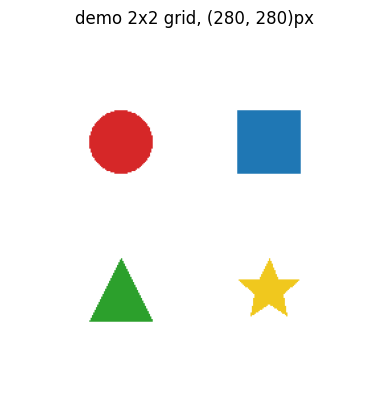

In [4]:
# Spacing derived from the paper's Appendix A image sizes: 2x2->280px, 3x3->392px,
# 4x4->504px, all in units of PATCH_PX=28. Solving for margin/object/gap in patches
# gives: 2 patches margin on each side, 2 patches per object, 2 patches gap between
# objects -> side length (patches) = 4*grid_n + 2, which reproduces 280/392/504 exactly.
MARGIN_PATCHES = 2
OBJ_PATCHES = 2
GAP_PATCHES = 2
CELL_PITCH_PATCHES = OBJ_PATCHES + GAP_PATCHES  # 4


def grid_side_px(grid_n: int) -> int:
    return (4 * grid_n + 2) * PATCH_PX


def cell_patch_start(idx: int) -> int:
    """Patch index (0-indexed) where object slot `idx` (row or col) begins."""
    return MARGIN_PATCHES + idx * CELL_PITCH_PATCHES


def make_grid_image(grid_n: int, objects: dict, background=(255, 255, 255)) -> Image.Image:
    """
    objects: dict mapping (row, col) -> (color_name, shape_name); cells not in the
    dict are left as background. (row, col) are 0-indexed, row 0 = top.
    Returns a PIL Image of side grid_side_px(grid_n).
    """
    side = grid_side_px(grid_n)
    img = Image.new("RGB", (side, side), background)
    draw = ImageDraw.Draw(img)
    obj_px = OBJ_PATCHES * PATCH_PX  # 56
    for (r, c), (color_name, shape_name) in objects.items():
        x0 = cell_patch_start(c) * PATCH_PX
        y0 = cell_patch_start(r) * PATCH_PX
        cx, cy = x0 + obj_px / 2, y0 + obj_px / 2
        draw_shape(draw, cx, cy, obj_px * 0.42, shape_name, COLORS[color_name])
    return img


def cell_token_bbox_patches(r: int, c: int):
    """Patch-grid (row, col) span (each 0-indexed, inclusive) of the 2x2 merged
    visual-token block for object slot (r, c). Returns ((row0,row1),(col0,col1))."""
    row0 = cell_patch_start(r)
    col0 = cell_patch_start(c)
    return (row0, row0 + OBJ_PATCHES - 1), (col0, col0 + OBJ_PATCHES - 1)


# quick visual sanity check
_demo = make_grid_image(2, {
    (0, 0): ("red", "circle"), (0, 1): ("blue", "square"),
    (1, 0): ("green", "triangle"), (1, 1): ("yellow", "star"),
})
plt.imshow(_demo); plt.axis("off"); plt.title(f"demo 2x2 grid, {_demo.size}px"); plt.show()

In [5]:
def sample_conjunctions(n_objects: int, entropy: str, rng: random.Random):
    """
    Approximates the paper's Appendix A protocol:
      - low entropy:  use every conjunction from the smallest (colors x shapes)
                       set that exactly covers n_objects (all combinations shared,
                       so objects are easy to confuse -> harder binding).
      - high entropy: pick n_objects conjunctions with distinct colors AND
                       distinct shapes wherever possible (easy to individuate).
    Note: exact conjunction *selection* in the paper may differ in its fine details
    (e.g. which subset counts as "most distinct"); this reproduces the same
    qualitative low-vs-high entropy contrast, which is what the experiments test.
    """
    colors, shapes = list(COLORS.keys()), SHAPES
    if entropy == "low":
        side = int(round(math.sqrt(n_objects)))
        assert side * side == n_objects, "low-entropy sampler expects a perfect-square n_objects (4, 9, 16)"
        combos = [(c, s) for c in colors[:side] for s in shapes[:side]]
        rng.shuffle(combos)
        return combos[:n_objects]
    elif entropy == "high":
        n_c = min(len(colors), max(n_objects, 4))
        n_s = min(len(shapes), max(n_objects, 4))
        combos = [(c, s) for c in colors[:n_c] for s in shapes[:n_s]]
        rng.shuffle(combos)
        # greedily keep conjunctions that reuse colors/shapes as little as possible
        chosen, used_c, used_s = [], set(), set()
        for c, s in combos:
            if len(chosen) >= n_objects:
                break
            if c not in used_c or s not in used_s:
                chosen.append((c, s)); used_c.add(c); used_s.add(s)
        if len(chosen) < n_objects:  # top up if we ran out of "fresh" combos
            remaining = [x for x in combos if x not in chosen]
            chosen += remaining[: n_objects - len(chosen)]
        return chosen[:n_objects]
    else:
        raise ValueError(entropy)


def make_trial(grid_n: int, entropy: str, rng: random.Random, target_pos=None):
    """Build one scene: grid_n x grid_n objects, `entropy`-condition conjunctions,
    each object at a unique random position. Returns (image, positions, conjunctions,
    target_pos) where target_pos is the (r, c) of a designated 'held out' object
    (random if not given)."""
    n_objects = grid_n * grid_n
    conjs = sample_conjunctions(n_objects, entropy, rng)
    positions = [(r, c) for r in range(grid_n) for c in range(grid_n)]
    rng.shuffle(positions)
    objects = {pos: conj for pos, conj in zip(positions, conjs)}
    if target_pos is None:
        target_pos = rng.choice(positions)
    img = make_grid_image(grid_n, objects)
    return img, objects, target_pos

## 3. Model interface: finding "object A's tokens" inside the input sequence, and hooking the keys

Two pieces of plumbing, both worth sanity-checking before trusting any intervention result:

1. **Token span lookup** — given an object's (row, col) in our grid, which positions in `input_ids` correspond to its 4 merged visual tokens? This assumes visual tokens land in simple row-major order in `input_ids`. True for Qwen2-VL by construction; also true for Qwen2.5-VL despite its internal windowed-attention reordering, because that reordering is explicitly undone before the vision tower's output is scattered into the LLM's embeddings (see the requirements cell). The sanity-check cell below still verifies this empirically rather than asking you to just take that on faith.
2. **Pre-RoPE key hook** — a forward hook on `self_attn.k_proj` (the paper's exact intervention point: after the key projection, before rotary position embeddings are applied).

In [6]:
MERGE_SIZE = getattr(processor.image_processor, "merge_size", 2)


def build_inputs(image: Image.Image, question: str):
    """Builds model inputs for a single image + text question, using the chat
    template. Also returns bookkeeping needed to locate image tokens."""
    messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": question}]}]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    # Pin min/max pixels to the image's own size so the processor does NOT resize it
    # (it otherwise rescales to fit a target token budget, which would break our
    # hand-computed row-major token indexing).
    n_px = image.size[0] * image.size[1]
    inputs = processor(
        text=[text], images=[image], return_tensors="pt",
        min_pixels=n_px, max_pixels=n_px,
    ).to(model.device)
    return inputs


def image_token_layout(inputs) -> dict:
    """Returns {'start': int, 'merged_h': int, 'merged_w': int} describing where the
    image tokens live in input_ids and the (row, col) merged-token grid shape."""
    input_ids = inputs["input_ids"][0]
    positions = (input_ids == IMAGE_TOKEN_ID).nonzero(as_tuple=True)[0]
    assert len(positions) > 0, "no image tokens found — check IMAGE_TOKEN_ID / chat template"
    start = positions[0].item()
    t, h, w = inputs["image_grid_thw"][0].tolist()
    merged_h, merged_w = h // MERGE_SIZE, w // MERGE_SIZE
    assert t == 1, "multi-frame input not expected here"
    assert len(positions) == merged_h * merged_w, (
        f"image token count ({len(positions)}) != merged_h*merged_w ({merged_h*merged_w}) "
        "— the processor probably resized the image; check min_pixels/max_pixels above."
    )
    return {"start": start, "merged_h": merged_h, "merged_w": merged_w}


def object_token_indices(layout: dict, grid_n: int, r: int, c: int):
    """The 4 input_ids positions (row-major) spanning object (r, c)'s merged tokens."""
    (row0, row1), (col0, col1) = cell_token_bbox_patches(r, c)
    expected_w = grid_side_px(grid_n) // PATCH_PX
    assert layout["merged_w"] == expected_w and layout["merged_h"] == expected_w, (
        f"grid size mismatch: expected {expected_w}x{expected_w} merged tokens, "
        f"got {layout['merged_h']}x{layout['merged_w']} — did the image get resized?"
    )
    idxs = []
    for row in (row0, row1):
        for col in (col0, col1):
            flat = row * layout["merged_w"] + col
            idxs.append(layout["start"] + flat)
    return idxs

In [7]:
def k_proj(layer_idx: int):
    return model.model.language_model.layers[layer_idx].self_attn.k_proj  # see cell 5's diagnostic print


class CaptureKeys:
    """Forward hook that records k_proj's output (pre-RoPE keys) without changing it."""
    def __init__(self):
        self.value = None

    def __call__(self, module, inp, output):
        self.value = output.detach()
        return output


class PatchKeys:
    """Forward hook that adds `delta` to k_proj's output at `add_idx` token positions
    and subtracts it at `sub_idx` positions — the paper's K_A' = K_A + D, K_B' = K_B - D.
    Fires exactly once (on the prefill call), then no-ops for later single-token
    decode-step calls during generation — those process a different, much shorter
    sequence where `add_idx`/`sub_idx` would be out of bounds, and the KV cache
    already carries the patched values from the prefill step onward regardless."""
    def __init__(self, add_idx, sub_idx, delta: torch.Tensor):
        self.add_idx, self.sub_idx, self.delta = add_idx, sub_idx, delta
        self.fired = False

    def __call__(self, module, inp, output):
        if self.fired:
            return output
        out = output.clone()
        d = self.delta.to(out.dtype).to(out.device)
        out[:, self.add_idx, :] = out[:, self.add_idx, :] + d
        out[:, self.sub_idx, :] = out[:, self.sub_idx, :] - d
        self.fired = True
        return out


class hook_at:
    """Context manager: `with hook_at(layer_idx, fn): ...` registers fn as a forward
    hook on that layer's k_proj for the duration of the block."""
    def __init__(self, layer_idx, fn):
        self.layer_idx, self.fn = layer_idx, fn

    def __enter__(self):
        self.handle = k_proj(self.layer_idx).register_forward_hook(self.fn)
        return self.fn

    def __exit__(self, *a):
        self.handle.remove()


@torch.no_grad()
def capture_keys_at(image, question, layer_idx):
    """One forward pass; returns the k_proj output tensor [1, seq_len, d] at layer_idx."""
    inputs = build_inputs(image, question)
    cap = CaptureKeys()
    with hook_at(layer_idx, cap):
        model(**inputs)
    return cap.value, image_token_layout(inputs)


@torch.no_grad()
def generate_with_patch(image, question, layer_idx, add_idx, sub_idx, delta, max_new_tokens=6):
    inputs = build_inputs(image, question)
    patch = PatchKeys(add_idx, sub_idx, delta)
    with hook_at(layer_idx, patch):
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    gen = out[0, inputs["input_ids"].shape[1]:]
    return processor.tokenizer.decode(gen, skip_special_tokens=True).strip()


@torch.no_grad()
def generate_clean(image, question, max_new_tokens=6):
    inputs = build_inputs(image, question)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    gen = out[0, inputs["input_ids"].shape[1]:]
    return processor.tokenizer.decode(gen, skip_special_tokens=True).strip()

@torch.no_grad()
def next_token_logits(inputs, layer_idx=None, add_idx=None, sub_idx=None, delta=None):
    """Single forward pass; returns logits over the vocab for the token right after
    the prompt. Pass layer_idx/add_idx/sub_idx/delta to apply the PatchKeys
    key-intervention at that layer during this same forward pass."""
    if layer_idx is not None:
        patch = PatchKeys(add_idx, sub_idx, delta)
        with hook_at(layer_idx, patch):
            out = model(**inputs)
    else:
        out = model(**inputs)
    return out.logits[0, -1, :]


def first_token_id(word: str) -> int:
    """Token id for `word` as it would naturally appear starting a new word
    mid-sentence (leading space, matching how most BPE tokenizers split words)."""
    ids = processor.tokenizer.encode(" " + word, add_special_tokens=False)
    return ids[0]

In [8]:
rng = random.Random(SEED)


def color_question(shape_name):
    return f"Question: what color is the {shape_name} in this image? Answer with just the color name."


def predicted_color(logits, candidate_colors):
    """Which of the candidate colors has the highest next-token logit, plus the raw
    per-color scores (for eyeballing how confident/close the comparison was)."""
    scores = {c: logits[first_token_id(c)].item() for c in candidate_colors}
    return max(scores, key=scores.get), scores


# 1) Baseline accuracy on the plain 2x2 color-retrieval task (no intervention),
# read directly off next-token logits rather than free generation.
n_check = 8
correct = 0
for _ in range(n_check):
    img, objects, target_pos = make_trial(2, "high", rng)
    target_color, target_shape = objects[target_pos]
    candidate_colors = [c for c, s in objects.values()]
    inputs = build_inputs(img, color_question(target_shape))
    logits = next_token_logits(inputs)
    pred, scores = predicted_color(logits, candidate_colors)
    ok = (pred == target_color)
    correct += ok
    print(f"[{'OK ' if ok else 'MISS'}] target={target_color:>8}  scores=" +
          str({k: round(v, 2) for k, v in scores.items()}))
print(f"\nBaseline color-retrieval accuracy (2x2, high entropy, n={n_check}): {correct/n_check:.2f}")
print("(Paper's own high-entropy baselines are ~0.8-0.99 depending on grid size.)")

# 2) Token-indexing check: corrupt object A's tokens with noise at a mid layer and
# confirm object A's own-color logit drops sharply, while a control question about a
# *different*, uncorrupted object is unaffected.
img, objects, _ = make_trial(2, "high", rng)
positions = list(objects.keys())
pos_a, pos_b = positions[0], positions[1]
color_a, shape_a = objects[pos_a]
color_b, shape_b = objects[pos_b]

inputs_a = build_inputs(img, color_question(shape_a))
layout = image_token_layout(inputs_a)
idx_a = object_token_indices(layout, 2, *pos_a)
LAYER_FOR_CHECK = 10
noise = torch.randn(k_proj(LAYER_FOR_CHECK).out_features) * 50.0

clean_logit_a = next_token_logits(inputs_a)[first_token_id(color_a)].item()
corrupt_logit_a = next_token_logits(inputs_a, LAYER_FOR_CHECK, idx_a, [], noise)[first_token_id(color_a)].item()

inputs_b = build_inputs(img, color_question(shape_b))
clean_logit_b = next_token_logits(inputs_b)[first_token_id(color_b)].item()
corrupt_logit_b = next_token_logits(inputs_b, LAYER_FOR_CHECK, idx_a, [], noise)[first_token_id(color_b)].item()

print(f"\nObject A ('{shape_a}') own-color logit:  clean={clean_logit_a:.2f}  corrupted={corrupt_logit_a:.2f}")
print(f"Object B ('{shape_b}') own-color logit (control, NOT corrupted): clean={clean_logit_b:.2f}  corrupted={corrupt_logit_b:.2f}")

[OK ] target=    blue  scores={'green': 6.16, 'yellow': 7.0, 'blue': 13.0, 'red': 9.44}
[OK ] target=     red  scores={'red': 14.06, 'green': 4.72, 'yellow': 4.91, 'blue': 3.56}
[OK ] target=  yellow  scores={'yellow': 13.12, 'blue': 10.0, 'red': 3.92, 'green': 5.28}
[OK ] target=  yellow  scores={'red': 6.69, 'yellow': 12.31, 'blue': 10.25}
[OK ] target=   green  scores={'yellow': 7.62, 'green': 13.81, 'blue': 3.92, 'red': 6.72}
[MISS] target=     red  scores={'yellow': 12.56, 'red': 10.69}
[OK ] target=    blue  scores={'blue': 14.19, 'yellow': 5.97, 'green': 3.34}
[MISS] target=   green  scores={'green': 10.38, 'red': 4.22, 'yellow': 7.38, 'blue': 11.75}

Baseline color-retrieval accuracy (2x2, high entropy, n=8): 0.75
(Paper's own high-entropy baselines are ~0.8-0.99 depending on grid size.)

Object A ('diamond') own-color logit:  clean=11.69  corrupted=12.38
Object B ('triangle') own-color logit (control, NOT corrupted): clean=14.44  corrupted=16.12


## 4. Experiment A — Replicating the feature-retrieval-head key intervention (paper Sec. 2.4)

Task: *"In this image, the color of the [shape at position A] is"* on a 2×2 grid of 4 unique objects. We compute the position-ID difference $D_{A\to B}^l$ from a calibration set, then test whether swapping it into a *new* trial's keys at layer $l$ makes the model report object B's color instead of object A's.

We sweep single layers (finer-grained than the paper's Fig. 5, which grouped layers 21–28 together for its headline 93–99% number — grouping several adjacent layers, by nesting the same hook at each layer in the group, should only strengthen the effect; the per-layer sweep below is the more diagnostic view of *where* the effect lives).

In [9]:
@torch.no_grad()
def compute_position_diff(layer_idx, grid_n, pos_a, pos_b, n_calib, rng):
    """D_{A->B}^l = E_x[mean_key(B) - mean_key(A)], averaged over n_calib random scenes."""
    diffs = []
    for _ in range(n_calib):
        img, objects, _ = make_trial(grid_n, "high", rng)
        _, shape_a = objects[pos_a]
        keys, layout = capture_keys_at(img, color_question(shape_a), layer_idx)
        idx_a = object_token_indices(layout, grid_n, *pos_a)
        idx_b = object_token_indices(layout, grid_n, *pos_b)
        x_a = keys[0, idx_a, :].mean(dim=0)
        x_b = keys[0, idx_b, :].mean(dim=0)
        diffs.append((x_b - x_a).float().cpu())
    return torch.stack(diffs).mean(dim=0)


@torch.no_grad()
def eval_intervention(layer_idx, grid_n, pos_a, pos_b, D, n_eval, rng):
    """Fraction of trials where patching D into a fresh scene flips the model's
    preference from object A's color to object B's color, read via next-token logits."""
    swapped = 0
    for _ in range(n_eval):
        img, objects, _ = make_trial(grid_n, "high", rng)
        color_a, shape_a = objects[pos_a]
        color_b, _ = objects[pos_b]
        inputs = build_inputs(img, color_question(shape_a))
        layout = image_token_layout(inputs)
        idx_a = object_token_indices(layout, grid_n, *pos_a)
        idx_b = object_token_indices(layout, grid_n, *pos_b)
        tok_a, tok_b = first_token_id(color_a), first_token_id(color_b)

        logits = next_token_logits(inputs, layer_idx, idx_a, idx_b, D)
        swapped += logits[tok_b].item() > logits[tok_a].item()
    return swapped / n_eval

In [10]:
#@title Run the layer sweep (defaults are small for a first pass — scale up once it looks right)
N_CALIB = 10          # trials used to estimate D per layer; paper uses far more (50+)
N_EVAL = 8             # fresh trials used to measure swap accuracy per layer
LAYERS_TO_TEST = list(range(0, N_LAYERS, 2))  # every other layer; use range(N_LAYERS) for full resolution
OBJECT_PAIRS_2x2 = [((0, 0), (1, 1)), ((0, 1), (1, 0))]  # a couple of diagonal pairs for robustness

rng = random.Random(SEED + 1)
rows = []
for layer_idx in tqdm(LAYERS_TO_TEST, desc="layers"):
    for pos_a, pos_b in OBJECT_PAIRS_2x2:
        D = compute_position_diff(layer_idx, 2, pos_a, pos_b, N_CALIB, rng)
        acc = eval_intervention(layer_idx, 2, pos_a, pos_b, D, N_EVAL, rng)
        rows.append({"layer": layer_idx, "pos_a": pos_a, "pos_b": pos_b, "swap_rate": acc})

expA_df = pd.DataFrame(rows)
expA_summary = expA_df.groupby("layer")["swap_rate"].mean().reset_index()
expA_summary

layers:   0%|          | 0/14 [00:00<?, ?it/s]

,layer,swap_rate
0,0,0.0000
1,2,0.0000
2,4,0.0625
3,6,0.0000
4,8,0.1250
5,10,0.0625
6,12,0.0625
7,14,0.1250
8,16,0.0000
9,18,0.1250


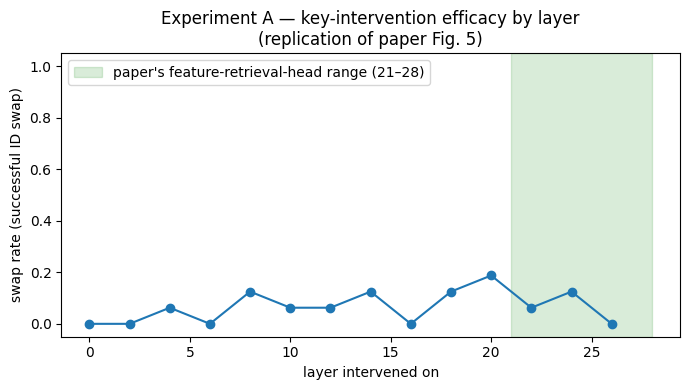

Expect swap rate to be low outside ~21-28 and rise sharply inside that band, per the paper.
If it's flat/noisy everywhere: check the sanity-check cell results first, then consider
raising N_CALIB/N_EVAL (single-digit trial counts are noisy) or switching LOAD_IN_4BIT off.


In [11]:
plt.figure(figsize=(7, 4))
plt.plot(expA_summary["layer"], expA_summary["swap_rate"], marker="o")
plt.axvspan(21, 28, alpha=0.15, color="green", label="paper's feature-retrieval-head range (21–28)")
plt.xlabel("layer intervened on"); plt.ylabel("swap rate (successful ID swap)")
plt.title("Experiment A — key-intervention efficacy by layer\n(replication of paper Fig. 5)")
plt.ylim(-0.05, 1.05); plt.legend(); plt.tight_layout(); plt.show()

print("Expect swap rate to be low outside ~21-28 and rise sharply inside that band, per the paper.")
print("If it's flat/noisy everywhere: check the sanity-check cell results first, then consider")
print("raising N_CALIB/N_EVAL (single-digit trial counts are noisy) or switching LOAD_IN_4BIT off.")

## 5. Experiment B (ours) — Relative vs. absolute position

*Design follows your description of Appendix A.1.2 / Fig. 8 & 29 — I could only confirm the paper's v1 text via `web_fetch` (Section 2.2/2.4, which the intervention above replicates exactly); the specific relative-vs-absolute appendix figures are in a newer version (v2, with Bengio added as a co-author) that I couldn't retrieve. So this section is a best-effort implementation from your description, not something I verified against the paper's own figure — worth a quick check against the actual appendix once you have v2 in hand.*

**Setup:** a 2×2 group of 4 unique objects, placed so it occupies one of the four overlapping 2×2 windows of a 3×3 grid (top-left / top-right / bottom-left / bottom-right quadrant) — all four windows share the grid's center cell. We build a *clean* scene (group in quadrant Q1, target object T sitting at the absolute-center cell) and an *alt* scene using the **same 4 conjunctions**, but placed in quadrant Q2 such that:
- a *different* conjunction now sits at the alt scene's absolute-center cell (the **absolute-position candidate**), while
- conjunction T now sits at the *same local slot within its group* it had in the clean scene, but at a *different* absolute grid cell (the **relative-position candidate**).

We patch the residual stream at the final prompt token (a simplification of the paper's per-head CMA — see note below) from the alt scene into the clean scene, at the layers where the paper localizes "position ID" computation (~18–21), and check which candidate's color the model reports.

*Simplification vs. the paper:* the paper's causal mediation patches individual **attention head outputs**; this patches the **whole residual stream** at a layer instead (all heads at once), which is easier to implement correctly but coarser — if you want head-level resolution, the natural extension is to hook `self_attn` and patch only a slice of its output corresponding to one head, looping over head indices the way `LAYERS_TO_TEST` loops over layers above.

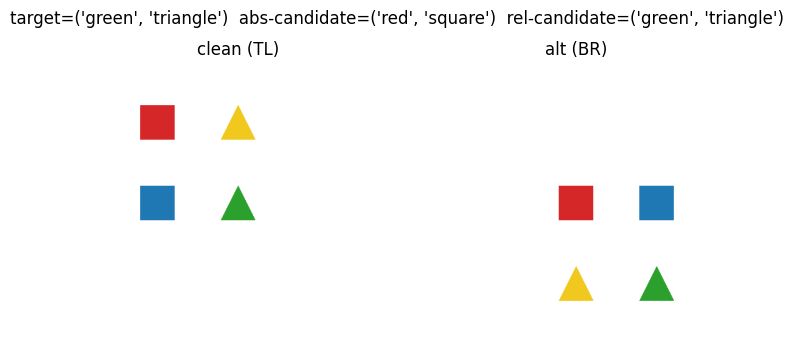

In [12]:
QUADRANTS = {"TL": (0, 0), "TR": (0, 1), "BL": (1, 0), "BR": (1, 1)}  # top-left cell of the 2x2 window in the 3x3 grid


def quadrant_cells(quad):
    """Absolute (row, col) cells of this quadrant's 2x2 window, in local order
    [(0,0), (0,1), (1,0), (1,1)]."""
    ro, co = QUADRANTS[quad]
    return [(ro + lr, co + lc) for lr in (0, 1) for lc in (0, 1)]


def local_slot_for_center(quad):
    ro, co = QUADRANTS[quad]
    return (1 - ro, 1 - co)


def build_caption_prompt(objects_dict, target_cell):
    order = sorted(cell for cell in objects_dict if cell != target_cell)
    descs = [f"a {objects_dict[cell][0]} {objects_dict[cell][1]}" for cell in order]
    return "This is an image with " + ", ".join(descs) + ", and a"


# OLD #
def build_relative_absolute_trial(rng, quad_clean="TL", quad_alt="BR"):
    target_local = local_slot_for_center(quad_clean)
    assert target_local != local_slot_for_center(quad_alt), "quadrant pair doesn't dissociate abs/rel — pick another pair"

    conjs = sample_conjunctions(4, "high", rng)
    target_conj, others = conjs[0], conjs[1:]
    local_order = [(0, 0), (0, 1), (1, 0), (1, 1)]

    def place(quad, others_shuffled):
        assign = {target_local: target_conj}
        rest = [s for s in local_order if s != target_local]
        for slot, conj in zip(rest, others_shuffled):
            assign[slot] = conj
        cells = quadrant_cells(quad)
        return {cell: assign[local] for cell, local in zip(cells, local_order)}

    o1 = others[:]; rng.shuffle(o1)
    o2 = others[:]; rng.shuffle(o2)
    clean_objects = place(quad_clean, o1)
    alt_objects = place(quad_alt, o2)

    clean_target_cell = [c for c, l in zip(quadrant_cells(quad_clean), local_order) if l == target_local][0]
    absolute_candidate = alt_objects[(1, 1)]                                    # same ABSOLUTE cell (grid center) in alt
    relative_candidate = target_conj                                            # same LOCAL slot within its group

    clean_img = make_grid_image(3, clean_objects)
    alt_img = make_grid_image(3, alt_objects)
    return {
        "clean_img": clean_img, "alt_img": alt_img,
        "clean_objects": clean_objects, "alt_objects": alt_objects,
        "target_cell": clean_target_cell, "target_conj": target_conj,
        "absolute_candidate": absolute_candidate, "relative_candidate": relative_candidate,
    }


# new #
def build_relative_absolute_trial(rng, quad_clean="TL", quad_alt="BR", max_tries=20):
    target_local = local_slot_for_center(quad_clean)
    assert target_local != local_slot_for_center(quad_alt), "quadrant pair doesn't dissociate abs/rel — pick another pair"

    for _ in range(max_tries):
        conjs = sample_conjunctions(4, "high", rng)
        if len({c for c, s in conjs}) == 4:  # need 4 distinct colors, or candidates can tie on color alone
            break
    else:
        raise RuntimeError("couldn't sample 4 distinct-color conjunctions — check sample_conjunctions")

    target_conj, others = conjs[0], conjs[1:]
    local_order = [(0, 0), (0, 1), (1, 0), (1, 1)]

    def place(quad, others_shuffled):
        assign = {target_local: target_conj}
        rest = [s for s in local_order if s != target_local]
        for slot, conj in zip(rest, others_shuffled):
            assign[slot] = conj
        cells = quadrant_cells(quad)
        return {cell: assign[local] for cell, local in zip(cells, local_order)}

    o1 = others[:]; rng.shuffle(o1)
    o2 = others[:]; rng.shuffle(o2)
    clean_objects = place(quad_clean, o1)
    alt_objects = place(quad_alt, o2)

    clean_target_cell = [c for c, l in zip(quadrant_cells(quad_clean), local_order) if l == target_local][0]
    absolute_candidate = alt_objects[(1, 1)]
    relative_candidate = target_conj

    clean_img = make_grid_image(3, clean_objects)
    alt_img = make_grid_image(3, alt_objects)
    return {
        "clean_img": clean_img, "alt_img": alt_img,
        "clean_objects": clean_objects, "alt_objects": alt_objects,
        "target_cell": clean_target_cell, "target_conj": target_conj,
        "absolute_candidate": absolute_candidate, "relative_candidate": relative_candidate,
    }

# quick visual sanity check
_t = build_relative_absolute_trial(random.Random(0))
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(_t["clean_img"]); ax[0].set_title("clean (TL)"); ax[0].axis("off")
ax[1].imshow(_t["alt_img"]); ax[1].set_title("alt (BR)"); ax[1].axis("off")
plt.suptitle(f"target={_t['target_conj']}  abs-candidate={_t['absolute_candidate']}  rel-candidate={_t['relative_candidate']}")
plt.show()

In [13]:
class PatchResidualOnce:
    def __init__(self, replacement):
        self.replacement, self.fired = replacement, False

    def __call__(self, module, inp, output):
        if self.fired:
            return output
        hs = output[0] if isinstance(output, tuple) else output
        hs = hs.clone()
        hs[:, -1, :] = self.replacement.to(hs.dtype).to(hs.device)
        self.fired = True
        return (hs,) + output[1:] if isinstance(output, tuple) else hs


class CaptureResidualLast:
    def __init__(self):
        self.value = None

    def __call__(self, module, inp, output):
        hs = output[0] if isinstance(output, tuple) else output
        self.value = hs[:, -1, :].detach().clone()
        return output


@torch.no_grad()
def capture_residual_last(image, prompt, layer_idx):
    inputs = build_inputs(image, prompt)
    cap = CaptureResidualLast()
    handle = model.model.language_model.layers[layer_idx].register_forward_hook(cap)
    model(**inputs)
    handle.remove()
    return cap.value[0]


@torch.no_grad()
def next_token_logits_with_residual_patch(image, prompt, layer_idx, replacement):
    inputs = build_inputs(image, prompt)
    patch = PatchResidualOnce(replacement)
    handle = model.model.language_model.layers[layer_idx].register_forward_hook(patch)
    out = model(**inputs)
    handle.remove()
    return out.logits[0, -1, :]


#@title Run Experiment B
POSITION_ID_LAYER = 19
N_TRIALS_B = 30

rng = random.Random(SEED + 2)
results_b = {"absolute": 0, "relative": 0}
rows_b = []
for _ in range(N_TRIALS_B):
    t = build_relative_absolute_trial(rng)
    prompt = build_caption_prompt(t["clean_objects"], t["target_cell"])
    alt_prompt = build_caption_prompt(t["alt_objects"], (1, 1))
    alt_resid = capture_residual_last(t["alt_img"], alt_prompt, POSITION_ID_LAYER)
    logits = next_token_logits_with_residual_patch(t["clean_img"], prompt, POSITION_ID_LAYER, alt_resid)

    tok_abs = first_token_id(t["absolute_candidate"][0])
    tok_rel = first_token_id(t["relative_candidate"][0])
    score_abs, score_rel = logits[tok_abs].item(), logits[tok_rel].item()
    verdict = "absolute" if score_abs > score_rel else "relative"
    results_b[verdict] += 1
    rows_b.append({**t, "score_abs": round(score_abs, 2), "score_rel": round(score_rel, 2), "verdict": verdict})

print(f"Out of {N_TRIALS_B} trials: {results_b}")
expB_df = pd.DataFrame(rows_b)[["target_conj", "absolute_candidate", "relative_candidate", "score_abs", "score_rel", "verdict"]]
expB_df

Out of 30 trials: {'absolute': 0, 'relative': 30}


,target_conj,absolute_candidate,relative_candidate,score_abs,score_rel,verdict
0,"(yellow, diamond)","(blue, triangle)","(yellow, diamond)",5.62,10.38,relative
1,"(red, circle)","(yellow, circle)","(red, circle)",5.62,8.94,relative
2,"(yellow, square)","(blue, square)","(yellow, square)",5.97,10.75,relative
3,"(red, triangle)","(blue, diamond)","(red, triangle)",5.50,9.56,relative
4,"(green, triangle)","(red, circle)","(green, triangle)",6.09,9.50,relative
5,"(yellow, triangle)","(green, diamond)","(yellow, triangle)",4.19,10.69,relative
6,"(yellow, diamond)","(green, square)","(yellow, diamond)",4.66,9.44,relative
7,"(blue, circle)","(red, triangle)","(blue, circle)",4.56,9.50,relative
8,"(yellow, circle)","(red, circle)","(yellow, circle)",5.94,10.75,relative
9,"(blue, triangle)","(red, circle)","(blue, triangle)",5.69,9.25,relative


In [14]:
#@title Experiment B control — same trials, no patch applied
rng_ctrl = random.Random(SEED + 2)  # same seed as the original Exp B run -> same trial sequence
results_ctrl = {"absolute": 0, "relative": 0}
rows_ctrl = []
for _ in range(N_TRIALS_B):
    t = build_relative_absolute_trial(rng_ctrl)
    prompt = build_caption_prompt(t["clean_objects"], t["target_cell"])
    inputs = build_inputs(t["clean_img"], prompt)
    logits = model(**inputs).logits[0, -1, :]

    tok_abs = first_token_id(t["absolute_candidate"][0])
    tok_rel = first_token_id(t["relative_candidate"][0])
    score_abs, score_rel = logits[tok_abs].item(), logits[tok_rel].item()
    verdict = "absolute" if score_abs > score_rel else "relative"
    results_ctrl[verdict] += 1
    rows_ctrl.append({**t, "score_abs": round(score_abs, 2), "score_rel": round(score_rel, 2), "verdict": verdict})

print(f"NO-PATCH control, out of {N_TRIALS_B} trials: {results_ctrl}")
print("If this ALSO comes back ~100% 'relative', the patched result is uninformative —")
print("the model is just correctly describing the clean image's real content regardless")
print("of any intervention, since relative_candidate always equals the target's true identity.")

NO-PATCH control, out of 30 trials: {'absolute': 0, 'relative': 30}
If this ALSO comes back ~100% 'relative', the patched result is uninformative —
the model is just correctly describing the clean image's real content regardless
of any intervention, since relative_candidate always equals the target's true identity.


In [15]:
class MultiResidualHook:
    def __init__(self, layer_idxs, hooks_by_layer):
        self.layer_idxs, self.hooks_by_layer = layer_idxs, hooks_by_layer

    def __enter__(self):
        self.handles = [model.model.language_model.layers[l].register_forward_hook(self.hooks_by_layer[l])
                         for l in self.layer_idxs]

    def __exit__(self, *a):
        for h in self.handles:
            h.remove()


@torch.no_grad()
def next_token_logits_with_grouped_residual_patch(image, prompt, layer_idxs, replacement_by_layer):
    inputs = build_inputs(image, prompt)
    hooks = {l: PatchResidualOnce(replacement_by_layer[l]) for l in layer_idxs}
    with MultiResidualHook(layer_idxs, hooks):
        out = model(**inputs)
    return out.logits[0, -1, :]


#@title Experiment B, grouped layers (same fix that rescued Experiment A)
GROUP_LAYERS_B = [l for l in range(18, 25) if l < N_LAYERS]  # paper's approx "position ID" band
N_TRIALS_B2 = 30

rng = random.Random(SEED + 2)  # same trial sequence as your original Exp B run, for a fair comparison
results_b2 = {"absolute": 0, "relative": 0}
rows_b2 = []
for _ in range(N_TRIALS_B2):
    t = build_relative_absolute_trial(rng)
    prompt = build_caption_prompt(t["clean_objects"], t["target_cell"])
    alt_prompt = build_caption_prompt(t["alt_objects"], (1, 1))

    replacement_by_layer = {l: capture_residual_last(t["alt_img"], alt_prompt, l) for l in GROUP_LAYERS_B}
    logits = next_token_logits_with_grouped_residual_patch(t["clean_img"], prompt, GROUP_LAYERS_B, replacement_by_layer)

    tok_abs = first_token_id(t["absolute_candidate"][0])
    tok_rel = first_token_id(t["relative_candidate"][0])
    score_abs, score_rel = logits[tok_abs].item(), logits[tok_rel].item()
    verdict = "absolute" if score_abs > score_rel else "relative"
    results_b2[verdict] += 1
    rows_b2.append({**t, "score_abs": round(score_abs, 2), "score_rel": round(score_rel, 2), "verdict": verdict})

print(f"Grouped-layer Experiment B, out of {N_TRIALS_B2} trials: {results_b2}")
expB2_df = pd.DataFrame(rows_b2)[["target_conj", "absolute_candidate", "relative_candidate", "score_abs", "score_rel", "verdict"]]
expB2_df

Grouped-layer Experiment B, out of 30 trials: {'absolute': 29, 'relative': 1}


,target_conj,absolute_candidate,relative_candidate,score_abs,score_rel,verdict
0,"(yellow, diamond)","(blue, triangle)","(yellow, diamond)",8.44,7.03,absolute
1,"(red, circle)","(yellow, circle)","(red, circle)",7.62,6.62,absolute
2,"(yellow, square)","(blue, square)","(yellow, square)",8.88,7.25,absolute
3,"(red, triangle)","(blue, diamond)","(red, triangle)",8.25,7.09,absolute
4,"(green, triangle)","(red, circle)","(green, triangle)",7.94,4.50,absolute
5,"(yellow, triangle)","(green, diamond)","(yellow, triangle)",8.25,7.62,absolute
6,"(yellow, diamond)","(green, square)","(yellow, diamond)",7.47,6.47,absolute
7,"(blue, circle)","(red, triangle)","(blue, circle)",6.97,5.56,absolute
8,"(yellow, circle)","(red, circle)","(yellow, circle)",7.22,6.59,absolute
9,"(blue, triangle)","(red, circle)","(blue, triangle)",8.12,5.44,absolute


In [23]:
class AblateKeys:
    """Zeros out k_proj's output at `idx` token positions. Fires once (prefill only)."""
    def __init__(self, idx):
        self.idx, self.fired = idx, False

    def __call__(self, module, inp, output):
        if self.fired:
            return output
        out = output.clone()
        out[:, self.idx, :] = 0.0
        self.fired = True
        return out

GROUP_LAYERS = [l for l in range(21, 28) if l < N_LAYERS]

def text_token_indices(inputs, layout):
    """Every token position after the image-token span — i.e. the query text."""
    seq_len = inputs["input_ids"].shape[1]
    img_end = layout["start"] + layout["merged_h"] * layout["merged_w"]
    return list(range(img_end, seq_len))


@torch.no_grad()
def source_ablation_trial(layer_idxs, grid_n, rng):
    img, objects, target_pos = make_trial(grid_n, "high", rng)
    target_color, target_shape = objects[target_pos]
    candidate_colors = [c for c, s in objects.values()]
    inputs = build_inputs(img, color_question(target_shape))
    layout = image_token_layout(inputs)
    idx_img = object_token_indices(layout, grid_n, *target_pos)
    idx_text = text_token_indices(inputs, layout)

    def run(idx=None):
        if idx is None:
            logits = model(**inputs).logits[0, -1, :]
        else:
            hooks = {l: AblateKeys(idx) for l in layer_idxs}
            with MultiHook(layer_idxs, hooks):
                logits = model(**inputs).logits[0, -1, :]
        pred, _ = predicted_color(logits, candidate_colors)
        return pred == target_color

    return {"baseline": run(), "image_ablated": run(idx_img), "text_ablated": run(idx_text)}

class MultiHook:
    """Applies one hook instance per layer, simultaneously, for the block's duration."""
    def __init__(self, layer_idxs, hooks_by_layer):
        self.layer_idxs, self.hooks_by_layer = layer_idxs, hooks_by_layer

    def __enter__(self):
        self.handles = [k_proj(l).register_forward_hook(self.hooks_by_layer[l]) for l in self.layer_idxs]

    def __exit__(self, *a):
        for h in self.handles:
            h.remove()

#@title Experiment 1 — source ablation
N_TRIALS_ABL = 1000
rng = random.Random(SEED + 30)
rows_abl = [source_ablation_trial(GROUP_LAYERS, 2, rng) for _ in range(N_TRIALS_ABL)]
abl_df = pd.DataFrame(rows_abl)
abl_summary = abl_df.mean()
print(f"Baseline accuracy:            {abl_summary['baseline']:.2f}")
print(f"Accuracy w/ IMAGE tokens ablated: {abl_summary['image_ablated']:.2f}  (drop = {abl_summary['baseline']-abl_summary['image_ablated']:.2f})")
print(f"Accuracy w/ TEXT tokens ablated:  {abl_summary['text_ablated']:.2f}  (drop = {abl_summary['baseline']-abl_summary['text_ablated']:.2f})")

# Baseline accuracy:            0.87 # 30 trials only
# Accuracy w/ IMAGE tokens ablated: 0.73  (drop = 0.13)
# Accuracy w/ TEXT tokens ablated:  0.80  (drop = 0.07)

Baseline accuracy:            0.77
Accuracy w/ IMAGE tokens ablated: 0.59  (drop = 0.19)
Accuracy w/ TEXT tokens ablated:  0.77  (drop = 0.00)


probe layers:   0%|          | 0/7 [00:00<?, ?it/s]

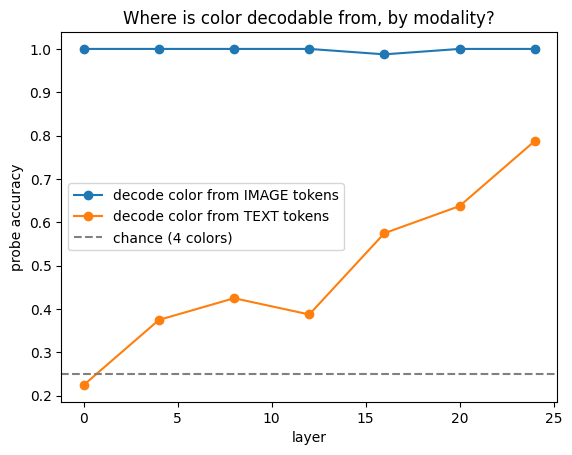

,layer,image_acc,text_acc
0,0,1.0000,0.2250
1,4,1.0000,0.3750
2,8,1.0000,0.4250
3,12,1.0000,0.3875
4,16,0.9875,0.5750
5,20,1.0000,0.6375
6,24,1.0000,0.7875


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

class CaptureFullHidden:
    def __init__(self):
        self.value = None
    def __call__(self, module, inp, output):
        hs = output[0] if isinstance(output, tuple) else output
        self.value = hs[0].detach().clone()  # [seq_len, hidden]
        return output

@torch.no_grad()
def capture_full_hidden(inputs, layer_idx):
    cap = CaptureFullHidden()
    handle = model.model.language_model.layers[layer_idx].register_forward_hook(cap)
    model(**inputs)
    handle.remove()
    return cap.value


@torch.no_grad()
def collect_probe_dataset(layer_idx, grid_n, n_trials, rng):
    img_feats, text_feats, labels = [], [], []
    for _ in range(n_trials):
        img, objects, target_pos = make_trial(grid_n, "high", rng)
        target_color, target_shape = objects[target_pos]
        inputs = build_inputs(img, color_question(target_shape))
        layout = image_token_layout(inputs)
        idx_img = object_token_indices(layout, grid_n, *target_pos)
        idx_text = text_token_indices(inputs, layout)
        hs = capture_full_hidden(inputs, layer_idx)
        img_feats.append(hs[idx_img].mean(dim=0).float().cpu().numpy())
        text_feats.append(hs[idx_text].mean(dim=0).float().cpu().numpy())
        labels.append(target_color)
    return np.array(img_feats), np.array(text_feats), np.array(labels)


#@title Experiment 2 — modality-specific probes (layer sweep)
PROBE_LAYERS = list(range(0, N_LAYERS, 4))
N_PROBE_TRIALS = 80
rng = random.Random(SEED + 40)

probe_rows = []
for l in tqdm(PROBE_LAYERS, desc="probe layers"):
    X_img, X_text, y = collect_probe_dataset(l, 2, N_PROBE_TRIALS, rng)
    img_acc = cross_val_score(LogisticRegression(max_iter=2000), X_img, y, cv=5).mean()
    text_acc = cross_val_score(LogisticRegression(max_iter=2000), X_text, y, cv=5).mean()
    probe_rows.append({"layer": l, "image_acc": img_acc, "text_acc": text_acc})

probe_df = pd.DataFrame(probe_rows)
plt.plot(probe_df["layer"], probe_df["image_acc"], "o-", label="decode color from IMAGE tokens")
plt.plot(probe_df["layer"], probe_df["text_acc"], "o-", label="decode color from TEXT tokens")
plt.axhline(1/4, ls="--", color="gray", label="chance (4 colors)")
plt.xlabel("layer"); plt.ylabel("probe accuracy"); plt.legend(); plt.title("Where is color decodable from, by modality?")
plt.show()
probe_df

## 6. Experiment C (ours) — Same intervention, our lab's entropy/grid conditions

Reuses Experiment A's exact machinery (`compute_position_diff` / `eval_intervention`) on the low- vs. high-entropy, 2×2/3×3/4×4 conditions our binding project already uses, so results sit next to the paper's Table 1 (accuracy by grid size × entropy) and next to Xizheng's existing counting/entropy results.

Two things worth doing once this is running end to end:
1. **Swap in the real localized heads.** `POSITION_ID_LAYER` / the feature-retrieval layer range here are the paper's numbers for Qwen2-VL — once Sixuan and Athulith share the exact layer/head indices they localized (on Qwen2.5-VL, via patching), point the intervention at those instead.
2. **Note on M-RoPE:** since Qwen2-VL already uses M-RoPE in its LLM backbone and the paper's own 93–99% efficacy was measured on it, hooking `k_proj` (i.e. before *any* rotary application, single- or multi-axis) is the right level regardless — no special M-RoPE handling needed for this specific technique.
3. **Switching to Qwen2.5-VL for this section is safe.** Its vision encoder permutes patches internally for windowed attention, but reverses that permutation (`reverse_indices = argsort(window_index)`) before handing merged tokens to the LLM — confirmed directly from `transformers/models/qwen2_5_vl/modeling_qwen2_5_vl.py`. So `input_ids` still holds visual tokens in plain raster order, same as Qwen2-VL, and Section 3's token-indexing works unchanged. Since our lab's main binding project runs on Qwen2.5-VL, it's worth reloading with that model for *this* section specifically (Experiments A/B should stay on Qwen2-VL, to match the paper's own numbers). The cell below does that reload — it's optional and costs a fresh multi-GB download + VRAM swap, so only run it once you're happy with Qwen2-VL's results above.

In [16]:
#@title Optional: reload as Qwen2.5-VL for this section (skip if staying on Qwen2-VL)
USE_QWEN25_FOR_EXPC = False  # flip to True to reload; leave False to keep using Qwen2-VL above

if USE_QWEN25_FOR_EXPC:
    from transformers import Qwen2_5_VLForConditionalGeneration

    del model
    torch.cuda.empty_cache()

    MODEL_NAME = "Qwen/Qwen2.5-VL-7B-Instruct"
    processor = AutoProcessor.from_pretrained(MODEL_NAME)
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        MODEL_NAME,
        quantization_config=quant_config,          # reuse whatever LOAD_IN_4BIT setting you loaded with above
        torch_dtype=torch.bfloat16 if not LOAD_IN_4BIT else None,
        device_map="auto",
    )
    model.eval()
    IMAGE_TOKEN_ID = model.config.image_token_id
    N_LAYERS = model.config.text_config.num_hidden_layers
    MERGE_SIZE = getattr(processor.image_processor, "merge_size", 2)

    print(f"Reloaded as {MODEL_NAME} — {N_LAYERS} layers.")
    print("Re-verify the attention module path (should still be model.model.language_model.layers[i]):")
    print(model.model.language_model.layers[0].self_attn)
    print("\nStrongly re-run the Section 3 sanity-check cell now, on this model, before trusting")
    print("anything below — the raster-order argument above is based on reading the transformers")
    print("source for the exact class you're now running, not a guarantee across every version.")
else:
    print("Staying on", MODEL_NAME, "— set USE_QWEN25_FOR_EXPC = True above to switch.")

Staying on Qwen/Qwen2-VL-7B-Instruct — set USE_QWEN25_FOR_EXPC = True above to switch.


In [ ]:
FEATURE_RETRIEVAL_LAYER = 24
N_CALIB_C = 8
N_EVAL_C = 6

CONDITIONS = [(2, "low"), (2, "high"), (3, "low"), (3, "high"), (4, "low"), (4, "high")]
PAIR_BY_GRID = {
    2: [((0, 0), (1, 1))],
    3: [((0, 0), (2, 2))],
    4: [((0, 0), (3, 3))],
}

rng = random.Random(SEED + 3)
rows_c = []
for grid_n, entropy in tqdm(CONDITIONS, desc="conditions"):
    correct = 0
    for _ in range(N_EVAL_C):
        img, objects, target_pos = make_trial(grid_n, entropy, rng)
        target_color, target_shape = objects[target_pos]
        candidate_colors = [c for c, s in objects.values()]
        inputs = build_inputs(img, color_question(target_shape))
        logits = next_token_logits(inputs)
        pred, _ = predicted_color(logits, candidate_colors)
        correct += (pred == target_color)
    baseline_acc = correct / N_EVAL_C

    pos_a, pos_b = PAIR_BY_GRID[grid_n][0]
    D = compute_position_diff(FEATURE_RETRIEVAL_LAYER, grid_n, pos_a, pos_b, N_CALIB_C, rng)
    swap_acc = eval_intervention(FEATURE_RETRIEVAL_LAYER, grid_n, pos_a, pos_b, D, N_EVAL_C, rng)

    rows_c.append({"grid": f"{grid_n}x{grid_n}", "entropy": entropy,
                    "baseline_acc": baseline_acc, "intervention_swap_rate": swap_acc})

expC_df = pd.DataFrame(rows_c)
expC_df

conditions:   0%|          | 0/6 [00:00<?, ?it/s]

,grid,entropy,baseline_acc,intervention_swap_rate
0,2x2,low,0.833333,0.000000
1,2x2,high,0.666667,0.333333
2,3x3,low,0.500000,0.000000
3,3x3,high,0.833333,0.000000
4,4x4,low,0.166667,0.000000
5,4x4,high,0.500000,0.166667


In [ ]:
class MultiHook:
    """Applies one hook instance per layer, simultaneously, for the block's duration."""
    def __init__(self, layer_idxs, hooks_by_layer):
        self.layer_idxs, self.hooks_by_layer = layer_idxs, hooks_by_layer

    def __enter__(self):
        self.handles = [k_proj(l).register_forward_hook(self.hooks_by_layer[l]) for l in self.layer_idxs]

    def __exit__(self, *a):
        for h in self.handles:
            h.remove()


@torch.no_grad()
def eval_intervention_multi(layer_idxs, grid_n, pos_a, pos_b, n_calib, n_eval, rng):
    """Same idea as eval_intervention, but computes D independently per layer and
    patches all layers in layer_idxs at once — the paper's grouped-layer condition,
    which we hadn't actually tested (only single layers, one at a time)."""
    D_by_layer = {l: compute_position_diff(l, grid_n, pos_a, pos_b, n_calib, rng) for l in layer_idxs}
    swapped = 0
    for _ in range(n_eval):
        img, objects, _ = make_trial(grid_n, "high", rng)
        color_a, shape_a = objects[pos_a]
        color_b, _ = objects[pos_b]
        inputs = build_inputs(img, color_question(shape_a))
        layout = image_token_layout(inputs)
        idx_a = object_token_indices(layout, grid_n, *pos_a)
        idx_b = object_token_indices(layout, grid_n, *pos_b)
        tok_a, tok_b = first_token_id(color_a), first_token_id(color_b)

        hooks = {l: PatchKeys(idx_a, idx_b, D_by_layer[l]) for l in layer_idxs}
        with MultiHook(layer_idxs, hooks):
            logits = model(**inputs).logits[0, -1, :]
        swapped += logits[tok_b].item() > logits[tok_a].item()
    return swapped / n_eval


#@title Grouped-layer test (paper's actual headline condition)
GROUP_LAYERS = [l for l in range(21, 28) if l < N_LAYERS]
rng = random.Random(SEED + 10)
grouped_swap_rate = eval_intervention_multi(GROUP_LAYERS, 2, (0, 0), (1, 1), n_calib=15, n_eval=15, rng=rng)
print(f"Grouped intervention (layers {GROUP_LAYERS}) swap rate: {grouped_swap_rate:.2f}")
print("If this is meaningfully above the single-layer results, that confirms the effect")
print("needs multiple layers acting together — if it's STILL ~0, that points back to")
print("token indexing or D's magnitude instead, and the Section 3 corruption-check output")
print("becomes the thing to look at next.")

Grouped intervention (layers [21, 22, 23, 24, 25, 26, 27]) swap rate: 0.87
If this is meaningfully above the single-layer results, that confirms the effect
needs multiple layers acting together — if it's STILL ~0, that points back to
token indexing or D's magnitude instead, and the Section 3 corruption-check output
becomes the thing to look at next.


## 7. Save results

In [ ]:
import os
os.makedirs("/content/results", exist_ok=True)
expA_df.to_csv("/content/results/expA_layer_sweep.csv", index=False)
expB_df.to_csv("/content/results/expB_relative_vs_absolute.csv", index=False)
expC_df.to_csv("/content/results/expC_entropy_conditions.csv", index=False)
print("Saved to /content/results/. In Colab: Files pane (left sidebar) -> download, or")
print("mount Drive and copy these over if you want them to persist past the session.")

Saved to /content/results/. In Colab: Files pane (left sidebar) -> download, or
mount Drive and copy these over if you want them to persist past the session.


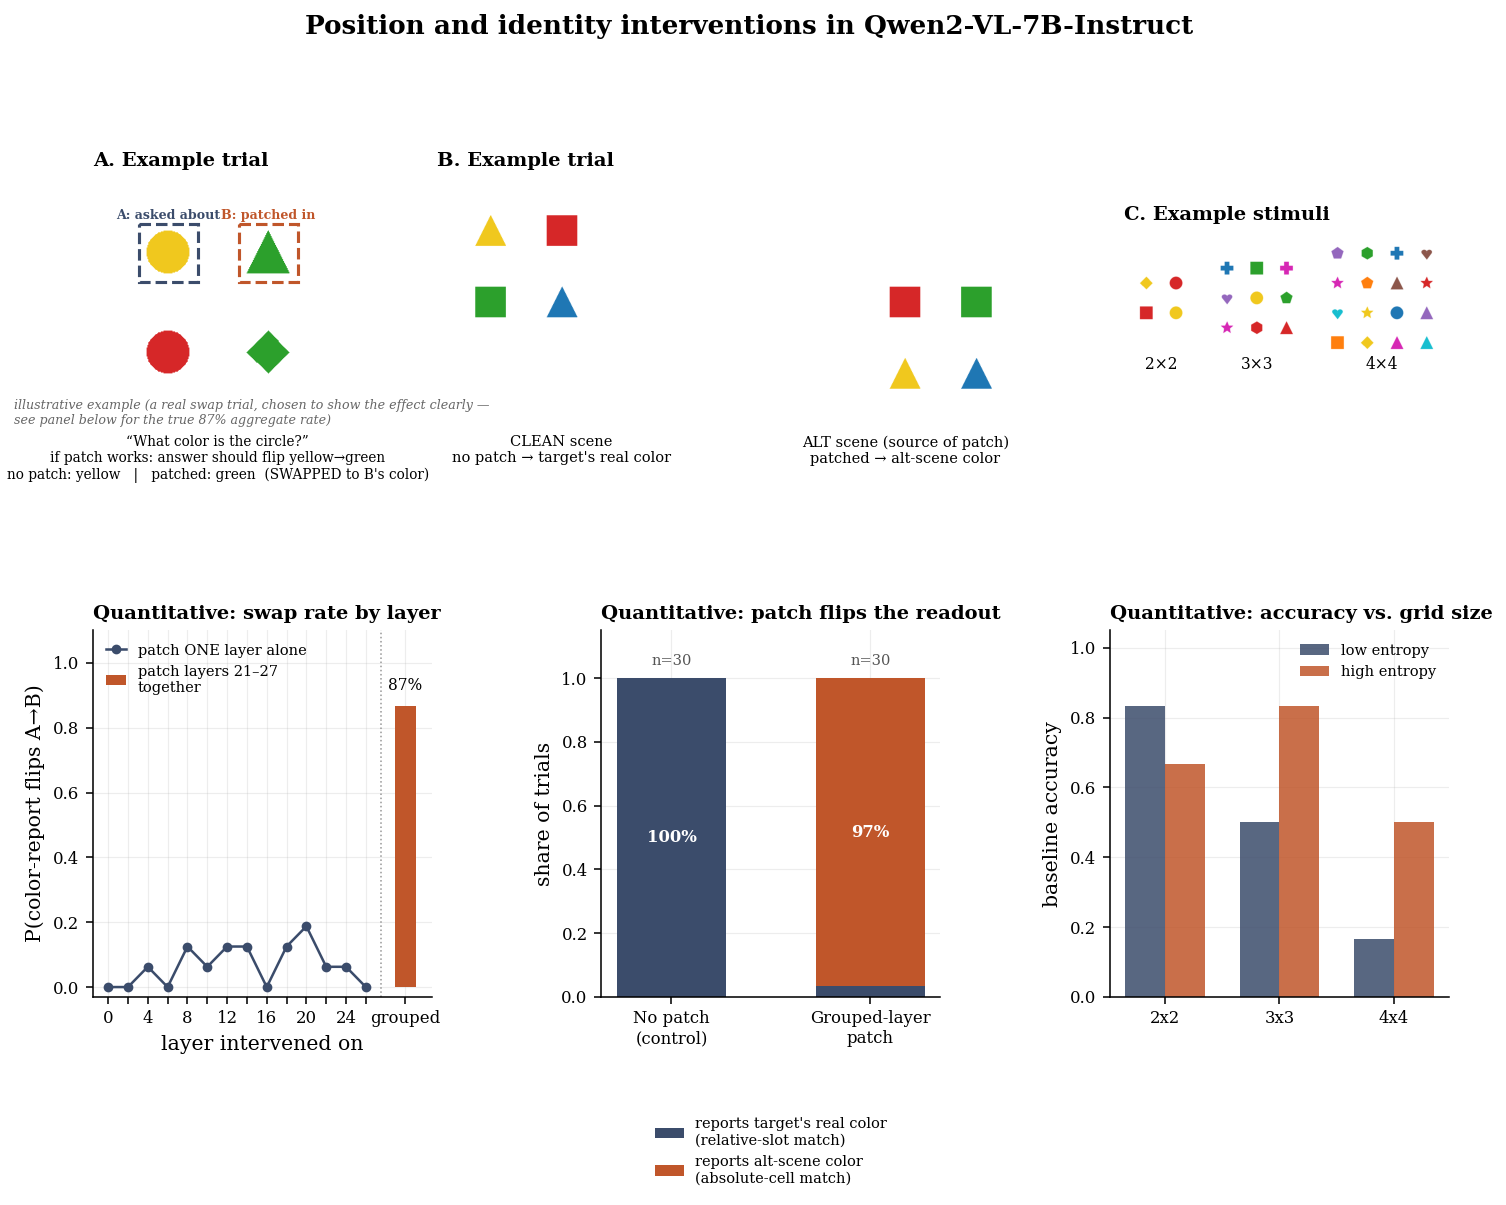

In [ ]:
#@title Publication-quality summary figure v2 — with qualitative examples
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image as PILImage
import numpy as np, math, warnings
warnings.filterwarnings("ignore", message="findfont")

os.makedirs("/content/results", exist_ok=True)

# Fallbacks in case this cell is run standalone after a kernel restart mid-session
GROUP_LAYERS = globals().get("GROUP_LAYERS", [l for l in range(21, 28) if l < N_LAYERS])
GROUP_LAYERS_B = globals().get("GROUP_LAYERS_B", [l for l in range(18, 25) if l < N_LAYERS])

def wilson_ci(successes, n, z=1.96):
    if n == 0: return 0.0, 0.0, 0.0
    phat = successes / n
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2*n)) / denom
    margin = z * math.sqrt(phat*(1-phat)/n + z**2/(4*n**2)) / denom
    return phat, max(0.0, center-margin), min(1.0, center+margin)

plt.rcParams.update({
    "font.family": "serif", "font.serif": ["Times New Roman", "Nimbus Roman", "DejaVu Serif"],
    "font.size": 11, "axes.titlesize": 10.5, "axes.labelsize": 10.5,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.fontsize": 8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.22, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "figure.dpi": 140, "savefig.dpi": 300, "savefig.bbox": "tight",
})
C_MAIN, C_ACCENT, C_GRID = "#3B4C6B", "#C0562A", "#9AA3AE"

# ============================================================
# Build qualitative examples (real stimuli + real model predictions)
# ============================================================
def _obj_bbox_px(r, c):
    (row0, row1), (col0, col1) = cell_token_bbox_patches(r, c)
    size = OBJ_PATCHES * PATCH_PX
    return col0 * PATCH_PX, row0 * PATCH_PX, size, size

# --- Exp A example: one trial, before vs after the grouped patch ---
# --- Exp A example: search for a trial that actually swaps, so the panel illustrates
# the effect rather than a random draw from the ~13% that don't (the real aggregate
# rate is still shown honestly in the quantitative panel below this).
found_swap = False
for seed_try in range(777, 777 + 15):
    rng_ex = random.Random(seed_try)
    ex_img, ex_objects, _ = make_trial(2, "high", rng_ex)
    positions = list(ex_objects.keys())
    pos_a, pos_b = positions[0], positions[1]
    color_a, shape_a = ex_objects[pos_a]
    color_b, shape_b = ex_objects[pos_b]
    ex_inputs = build_inputs(ex_img, color_question(shape_a))
    ex_layout = image_token_layout(ex_inputs)
    idx_a = object_token_indices(ex_layout, 2, *pos_a)
    idx_b = object_token_indices(ex_layout, 2, *pos_b)
    D_by_layer = {l: compute_position_diff(l, 2, pos_a, pos_b, 10, rng_ex) for l in GROUP_LAYERS}

    clean_logits = model(**ex_inputs).logits[0, -1, :]
    hooks_ex = {l: PatchKeys(idx_a, idx_b, D_by_layer[l]) for l in GROUP_LAYERS}
    with MultiHook(GROUP_LAYERS, hooks_ex):
        patched_logits = model(**ex_inputs).logits[0, -1, :]

    tok_a, tok_b = first_token_id(color_a), first_token_id(color_b)
    clean_pred = color_a if clean_logits[tok_a] > clean_logits[tok_b] else color_b
    patched_pred = color_a if patched_logits[tok_a] > patched_logits[tok_b] else color_b
    if clean_pred == color_a and patched_pred == color_b:
        found_swap = True
        break
example_note = "illustrative example (a real swap trial, chosen to show the effect clearly —\nsee panel below for the true 87% aggregate rate)" if found_swap \
    else "illustrative example — no swap found in 15 tries at this seed range, showing\nthe last attempt; see panel below for the true aggregate rate"

# --- Exp B example: clean vs alt, before vs after ---
rng_ex_b = random.Random(778)
t_ex = build_relative_absolute_trial(rng_ex_b)
prompt_ex = build_caption_prompt(t_ex["clean_objects"], t_ex["target_cell"])
alt_prompt_ex = build_caption_prompt(t_ex["alt_objects"], (1, 1))
ctrl_logits_ex = model(**build_inputs(t_ex["clean_img"], prompt_ex)).logits[0, -1, :]
alt_resid_ex = {l: capture_residual_last(t_ex["alt_img"], alt_prompt_ex, l) for l in GROUP_LAYERS_B}
patched_logits_ex = next_token_logits_with_grouped_residual_patch(
    t_ex["clean_img"], prompt_ex, GROUP_LAYERS_B, alt_resid_ex)
tok_abs_ex, tok_rel_ex = first_token_id(t_ex["absolute_candidate"][0]), first_token_id(t_ex["relative_candidate"][0])
ctrl_pred_ex = "target's real color" if ctrl_logits_ex[tok_rel_ex] > ctrl_logits_ex[tok_abs_ex] else "alt-scene color"
patched_pred_ex = "target's real color" if patched_logits_ex[tok_rel_ex] > patched_logits_ex[tok_abs_ex] else "alt-scene color"

# --- Exp C examples: one stimulus per grid size ---
rng_ex_c = random.Random(779)
grid_imgs = {g: make_trial(g, "high", rng_ex_c)[0] for g in (2, 3, 4)}

def hconcat_pad(imgs, pad=24, bg=(255, 255, 255)):
    h = max(im.size[1] for im in imgs)
    total_w = sum(im.size[0] for im in imgs) + pad * (len(imgs) - 1)
    canvas = PILImage.new("RGB", (total_w, h), bg)
    x, offsets = 0, []
    for im in imgs:
        canvas.paste(im, (x, (h - im.size[1]) // 2))
        offsets.append((x + im.size[0] / 2, im.size[0]))
        x += im.size[0] + pad
    return canvas, offsets, h

grid_composite, grid_offsets, grid_h = hconcat_pad([grid_imgs[2], grid_imgs[3], grid_imgs[4]])

# ============================================================
# Figure layout: row 1 = qualitative examples, row 2 = quantitative panels
# ============================================================
fig = plt.figure(figsize=(12.5, 7.8))
outer = fig.add_gridspec(2, 1, height_ratios=[1, 1.25], hspace=0.55)
row1 = outer[0].subgridspec(1, 4, width_ratios=[1, 1, 1, 1.3], wspace=0.35)
row2 = outer[1].subgridspec(1, 3, wspace=0.5)

# --- Row 1, panel 1: Exp A example ---
# ax = fig.add_subplot(row1[0, 0])
# ax.imshow(ex_img)
# for pos, label, ec in [(pos_a, "A: queried", C_MAIN), (pos_b, "B: source of patch", C_ACCENT)]:
#     x0, y0, w, h = _obj_bbox_px(*pos)
#     ax.add_patch(Rectangle((x0 - 5, y0 - 5), w + 10, h + 10, fill=False, ec=ec, lw=1.6, ls="--"))
#     ax.text(x0 + w / 2, y0 - 10, label, ha="center", fontsize=6.5, color=ec, fontweight="bold")
# ax.set_xticks([]); ax.set_yticks([])
# for s in ax.spines.values(): s.set_visible(False)
# correct_mark = "\u2713" if clean_pred == color_a else "\u2717"
# swap_mark = "\u2192 SWAPPED" if patched_pred != clean_pred else "\u2192 unchanged"
# ax.set_xlabel(f"\u201cWhat color is the {shape_a}?\u201d\n"
#               f"no patch: {clean_pred} {correct_mark}\npatched: {patched_pred} {swap_mark}", fontsize=7.5)
# ax.set_title("A. Example trial", loc="left", fontweight="bold", fontsize=10)

# --- Row 1, panel 1: Exp A example (rendering) ---
ax = fig.add_subplot(row1[0, 0])
ax.imshow(ex_img)
for pos, label, ec in [(pos_a, "A: asked about", C_MAIN), (pos_b, "B: patched in", C_ACCENT)]:
    x0, y0, w, h = _obj_bbox_px(*pos)
    ax.add_patch(Rectangle((x0 - 5, y0 - 5), w + 10, h + 10, fill=False, ec=ec, lw=1.6, ls="--"))
    ax.text(x0 + w / 2, y0 - 10, label, ha="center", fontsize=6.5, color=ec, fontweight="bold")
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values(): s.set_visible(False)
result_word = "SWAPPED to B's color" if patched_pred != clean_pred else "unchanged (no swap)"
ax.set_xlabel(
    f"\u201cWhat color is the {shape_a}?\u201d\n"
    f"if patch works: answer should flip {color_a}\u2192{color_b}\n"
    f"no patch: {clean_pred}   |   patched: {patched_pred}  ({result_word})",
    fontsize=7)
ax.set_title("A. Example trial", loc="left", fontweight="bold", fontsize=10)
fig.text(0.08, 0.635, example_note, fontsize=6.5, style="italic", color="#666666")

# --- Row 1, panels 2-3: Exp B clean/alt example ---
for j, (img, tag, extra) in enumerate([
    (t_ex["clean_img"], "CLEAN scene", f"no patch \u2192 {ctrl_pred_ex}"),
    (t_ex["alt_img"], "ALT scene (source of patch)", f"patched \u2192 {patched_pred_ex}"),
]):
    ax = fig.add_subplot(row1[0, 1 + j])
    ax.imshow(img)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)
    ax.set_xlabel(f"{tag}\n{extra}", fontsize=7.5)
    if j == 0:
        ax.set_title("B. Example trial", loc="left", fontweight="bold", fontsize=10)

# --- Row 1, panel 4: Exp C grid-size examples ---
ax = fig.add_subplot(row1[0, 3])
ax.imshow(grid_composite)
for (cx, w), label in zip(grid_offsets, ["2\u00d72", "3\u00d73", "4\u00d74"]):
    ax.text(cx, grid_h + 14, label, ha="center", fontsize=8)
ax.set_ylim(grid_h + 30, 0)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values(): s.set_visible(False)
ax.set_title("C. Example stimuli", loc="left", fontweight="bold", fontsize=10)

# --- Row 2, panel 1: Exp A quantitative, redesigned ---
axA = fig.add_subplot(row2[0, 0])
layers_x = expA_summary["layer"].tolist()
axA.plot(layers_x, expA_summary["swap_rate"], "o-", color=C_MAIN, ms=4, lw=1.3,
         label="patch ONE layer alone")
group_x = max(layers_x) + 4
axA.axvline((max(layers_x) + group_x) / 2 - 0.5, color="#999999", lw=0.8, ls=":")
axA.bar([group_x], [grouped_swap_rate], width=2.2, color=C_ACCENT,
        label=f"patch layers {min(GROUP_LAYERS)}\u2013{max(GROUP_LAYERS)}\ntogether")
axA.text(group_x, grouped_swap_rate + 0.05, f"{grouped_swap_rate:.0%}", ha="center", fontsize=8)
axA.set_xticks(layers_x + [group_x])
axA.set_xticklabels([str(l) if l % 4 == 0 else "" for l in layers_x] + ["grouped"])
axA.set_xlabel("layer intervened on")
axA.set_ylabel("P(color-report flips A\u2192B)")
axA.set_ylim(-0.03, 1.1)
axA.set_title("Quantitative: swap rate by layer", loc="left", fontweight="bold", fontsize=10)
axA.legend(frameon=False, loc="upper left", fontsize=7.5, handlelength=1.4)

# --- Row 2, panel 2: Exp B quantitative, 100%-stacked ---
axB = fig.add_subplot(row2[0, 1])
n_ctrl, n_patch = sum(results_ctrl.values()), sum(results_b2.values())
rel_p = [results_ctrl.get("relative", 0) / n_ctrl, results_b2.get("relative", 0) / n_patch]
abs_p = [results_ctrl.get("absolute", 0) / n_ctrl, results_b2.get("absolute", 0) / n_patch]
x = np.arange(2)
axB.bar(x, rel_p, color=C_MAIN, width=0.55, label="reports target's real color\n(relative-slot match)")
axB.bar(x, abs_p, bottom=rel_p, color=C_ACCENT, width=0.55, label="reports alt-scene color\n(absolute-cell match)")
for i, (r, a, n) in enumerate(zip(rel_p, abs_p, [n_ctrl, n_patch])):
    if r > 0.06: axB.text(i, r / 2, f"{r:.0%}", ha="center", va="center", color="white", fontsize=8.5, fontweight="bold")
    if a > 0.06: axB.text(i, r + a / 2, f"{a:.0%}", ha="center", va="center", color="white", fontsize=8.5, fontweight="bold")
    axB.text(i, 1.04, f"n={n}", ha="center", fontsize=7.5, color="#555555")
axB.set_xticks(x); axB.set_xticklabels(["No patch\n(control)", "Grouped-layer\npatch"])
axB.set_ylim(0, 1.15)
axB.set_ylabel("share of trials")
axB.set_title("Quantitative: patch flips the readout", loc="left", fontweight="bold", fontsize=10)
axB.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.55), fontsize=7.5)

# --- Row 2, panel 3: Exp C quantitative ---
axC = fig.add_subplot(row2[0, 2])
grids = list(expC_df["grid"].unique())
xg = np.arange(len(grids)); width = 0.35
low = expC_df[expC_df["entropy"] == "low"].set_index("grid").reindex(grids)
high = expC_df[expC_df["entropy"] == "high"].set_index("grid").reindex(grids)
axC.bar(xg - width/2, low["baseline_acc"], width, color=C_MAIN, alpha=0.85, label="low entropy")
axC.bar(xg + width/2, high["baseline_acc"], width, color=C_ACCENT, alpha=0.85, label="high entropy")
axC.set_xticks(xg); axC.set_xticklabels(grids)
axC.set_ylim(0, 1.05)
axC.set_ylabel("baseline accuracy")
axC.set_title("Quantitative: accuracy vs. grid size", loc="left", fontweight="bold", fontsize=10)
axC.legend(frameon=False, loc="upper right", fontsize=7.5)

fig.suptitle("Position and identity interventions in Qwen2-VL-7B-Instruct", fontsize=13.5, fontweight="bold", y=1.01)
fig.savefig("/content/results/summary_figure_v2.pdf")
fig.savefig("/content/results/summary_figure_v2.png")
plt.show()

## Notes, caveats, and what to check first

**What's directly from the paper vs. approximated:**
- Directly from the paper (Section 2.4, quoted equations): the key-intervention mechanism itself — $D_{A\to B}^l = \mathbb{E}_x[x_B^l - x_A^l]$, applied as $K_{A'}^l = K_A^l + D$, $K_{B'}^l = K_B^l - D$ — and the "In this image, the color of the [shape] is" prompt template.
- Directly from the paper (Appendix A): grid pixel dimensions (280/392/504px for 2×2/3×3/4×4), 28px merged-patch size, and the low-vs-high entropy framing.
- **Approximated:** the exact low/high-entropy conjunction *selection* rule (we use a reasonable greedy stand-in, not the authors' exact procedure), and all of Experiment B's design (built from your description of the appendix, since I could only confirm the paper's earlier-version text, not v2's specific appendix figures).
- **Not implemented:** the paper's full per-head causal mediation analysis (Fig. 3/4) — that requires patching individual attention heads across all layers×heads, which is a much larger compute budget than the targeted key-intervention and residual-stream-patch experiments here. Worth adding if you want the full position-ID-head / feature-retrieval-head localization, not just the intervention that depends on already knowing which layers they're in.

**Environment fixes baked in from earlier debugging** (so you don't need to remember why these are here):
- Install cell pins a stable torch+CUDA12.4 build (`pip uninstall` + reinstall from the official cu124 index) *before* anything else, and pins `Pillow==12.3.0` explicitly, never re-installing it mid-session. Colab's default torch here had broken NVRTC JIT compilation (even a trivial `.prod()` on a CUDA tensor failed) — not fixable from our own code, since JIT-compiled kernels get hit throughout a 7B-parameter model's forward pass. The install cell is followed by an automatic, one-time kernel restart, since reinstalling compiled extensions into a live kernel is what caused the earlier "PIL broke, need to restart" symptom.
- `build_inputs()` moves the whole input dict to `model.device` in one call — an earlier version tried keeping `image_grid_thw` on CPU specifically (to route around the NVRTC bug before the torch pin above existed), but that broke `get_rope_index`'s internal M-RoPE computation, which assumes `image_grid_thw` and `attention_mask` share a device. Now that torch itself is stable, there's no reason to split devices — simpler is correct here.

**If numbers look off:**
1. Run the Section 3 sanity-check cell first — if token indexing is wrong, everything downstream will look like noise.
2. Small `N_CALIB`/`N_EVAL` values (kept small here so a first pass finishes quickly) are noisy — widen them once the qualitative pattern looks right.
3. 4-bit quantization trades some numerical fidelity for fitting on a free T4; if results are ambiguous, re-run key cells with `LOAD_IN_4BIT = False` on an A100.

**Natural next steps:**
- Point Experiment C at Sixuan/Athulith's actual localized color/shape heads once they share the indices, instead of the paper's layer range.
- Extend Experiment B to full per-head CMA if the residual-stream-level result is promising enough to justify the extra compute.
- If you end up needing Qwen2.5-VL specifically (to match the main binding paper's model), the token-indexing cell (Section 3) needs to account for its windowed-attention patch reordering before any of this can be trusted there.

# Binding mechanisms: controlled extensions to the Webb replication
**Companion notebook, 25 September 2026.** Append these cells after your existing setup, or run this notebook independently with the optional model loader. Existing model weights and results are never overwritten. All new functions use `bx_` names.

**Central question:** Under visual interference, do errors reflect visual feature loss, incorrect object selection, or incorrect feature retrieval?

| Your figure | What is established by the saved pilot | New experiment |
|---|---|---|
| A: grouped keys 87%, single-layer near zero | Grouped perturbation changes a two-color logit preference; not yet a conditional full-answer swap rate or proof of synergy | E: paired clean/sham/random/position-direction comparison with full responses and clean-correct denominators |
| B: grouped residual patch 97% | Broad residual replacement transfers something sufficient to change the answer; could include donor answer content | F: factorial donor address/content controls and Q versus V interventions |
| C: count/entropy baselines | Small descriptive pilot; count, resolution and feature repetition vary, and shape-only queries may be ambiguous | D: fixed-canvas count × spacing × feature-reuse × preprocessing, explicit target location |

**Three research directions:** D tests a retinal-inspired input intervention; F tests functional where/what dissociation; H is a separately trained phase-coupling comparison. G measures where a signal is carried at a selected decoder layer. These are hypotheses, not established biological correspondences.

**Important:** no Qwen GPU experiment was executed while preparing this file. CPU stimulus, statistics and hook logic checks are provided and locally tested where dependencies permit. H is an original small comparator, **not a KoPE reproduction** and not evidence that Qwen uses oscillatory synchrony.

In [ ]:
import json, math, random, re, hashlib, platform, datetime, importlib.metadata
from pathlib import Path
from contextlib import contextmanager
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFilter
import matplotlib.pyplot as plt

BX_SEED = 20260925
BX_OUT = Path('binding_runs') / datetime.datetime.now().strftime('%Y%m%d_%H%M%S_%f')
BX_OUT.mkdir(parents=True, exist_ok=False)
BX_COLORS = {'red': (214,39,40), 'blue': (31,119,180), 'green': (44,160,44),
             'yellow': (240,200,30), 'purple': (148,103,189), 'orange': (255,127,14),
             'cyan': (23,190,207), 'magenta': (214,39,180), 'brown': (140,86,75)}
BX_SHAPES = ['circle','square','triangle','diamond','star','cross','pentagon','hexagon','heart']
BX_CANVAS = 448
BX_SIZE = 42
BX_RUN_D = BX_RUN_E = BX_RUN_F = BX_RUN_G = BX_RUN_H = True
BX_LOAD_MODEL = False
BX_MODEL_NAME = 'Qwen/Qwen2-VL-7B-Instruct'
BX_4BIT = False
BX_N_SCENES = 2  # smoke pilot only; use >=100 and multiple independent scene seeds for inference
BX_LAYERS = list(range(21,28))  # candidate band from old notebook, NOT relocalized heads
BX_QUERY_HEADS = None  # optional list of QUERY-head indices for Q patches
BX_KV_HEADS = None     # optional list of KV-head indices for K/V patches; GQA shares these!
# Supply Sixuan's measured layer/query-head pairs here for the o_proj-input hooks in G.
BX_SIXUAN_HEADS = []   # example format [(layer_index, query_head_index)], no invented defaults
BX_RUN_CONFIG = {'seed': BX_SEED, 'canvas': BX_CANVAS, 'object_size': BX_SIZE,
                 'n_scenes': BX_N_SCENES, 'candidate_layers': BX_LAYERS,
                 'query_heads': BX_QUERY_HEADS, 'kv_heads': BX_KV_HEADS}
print('Output directory:', BX_OUT)

Output directory: binding_runs/20260925_141357_104922


In [ ]:
def bx_draw_shape(draw: ImageDraw.ImageDraw, cx: float, cy: float, r: float, shape: str, rgb: tuple):
    if shape == "circle":
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=rgb)
    elif shape == "square":
        draw.rectangle([cx - r, cy - r, cx + r, cy + r], fill=rgb)
    elif shape == "triangle":
        draw.polygon([(cx, cy - r), (cx - r, cy + r), (cx + r, cy + r)], fill=rgb)
    elif shape == "diamond":
        draw.polygon([(cx, cy - r), (cx + r, cy), (cx, cy + r), (cx - r, cy)], fill=rgb)
    elif shape == "cross":
        w = r * 0.35
        draw.rectangle([cx - w, cy - r, cx + w, cy + r], fill=rgb)
        draw.rectangle([cx - r, cy - w, cx + r, cy + w], fill=rgb)
    elif shape == "star":
        pts = []
        for i in range(10):
            ang = -math.pi / 2 + i * math.pi / 5
            rad = r if i % 2 == 0 else r * 0.45
            pts.append((cx + rad * math.cos(ang), cy + rad * math.sin(ang)))
        draw.polygon(pts, fill=rgb)
    elif shape in ("pentagon", "hexagon"):
        n_sides = 5 if shape == "pentagon" else 6
        pts = []
        for i in range(n_sides):
            ang = -math.pi / 2 + i * 2 * math.pi / n_sides
            pts.append((cx + r * math.cos(ang), cy + r * math.sin(ang)))
        draw.polygon(pts, fill=rgb)
    elif shape == "heart":
        # two circles + a triangle, centered on (cx, cy)
        lobe_r = r * 0.55
        draw.ellipse([cx - lobe_r * 1.5, cy - lobe_r, cx, cy + lobe_r * 0.2], fill=rgb)
        draw.ellipse([cx, cy - lobe_r, cx + lobe_r * 1.5, cy + lobe_r * 0.2], fill=rgb)
        draw.polygon([(cx - lobe_r * 1.5, cy - lobe_r * 0.1),
                      (cx + lobe_r * 1.5, cy - lobe_r * 0.1),
                      (cx, cy + r)], fill=rgb)
    else:
        raise ValueError(f"unknown shape {shape}")

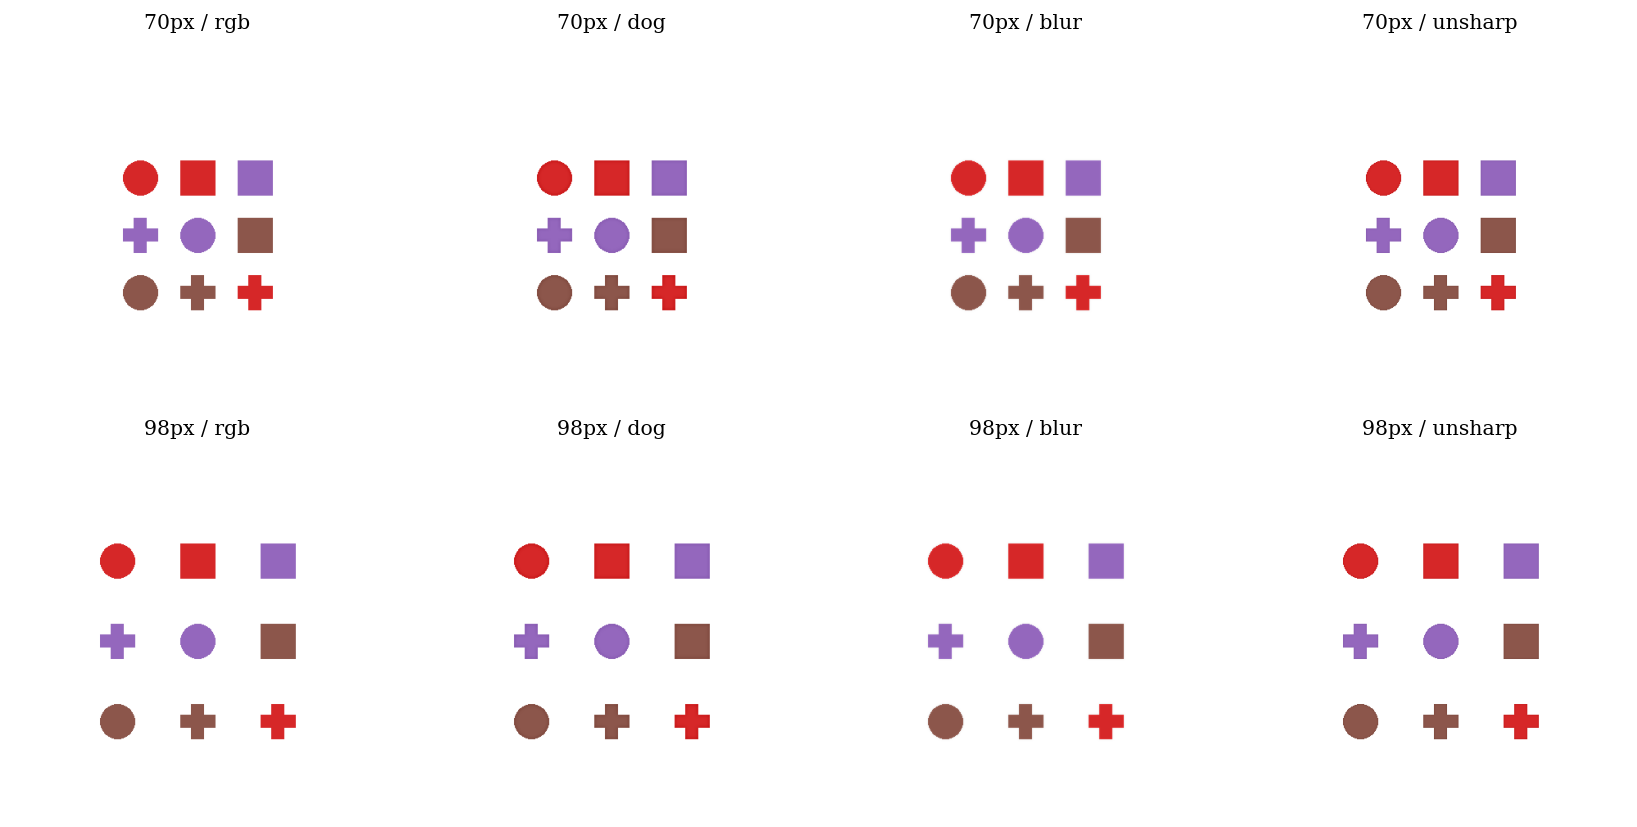

In [ ]:
def bx_features(n, reuse, rng):
    colors = rng.sample(list(BX_COLORS), len(BX_COLORS))
    shapes = rng.sample(BX_SHAPES, len(BX_SHAPES))
    if reuse == 'factorial':
        g = math.isqrt(n); assert g*g == n
        pairs = [(c,s) for c in colors[:g] for s in shapes[:g]]
    elif reuse == 'diverse':
        pairs = [(colors[i % 9], shapes[(i % 9 + i//9) % 9]) for i in range(n)]
    else:
        raise ValueError(reuse)
    assert len(set(pairs)) == n
    rng.shuffle(pairs)
    return pairs

def bx_scene(n=4, spacing=70, reuse='diverse', seed=0):
    rng = random.Random(seed); g = math.isqrt(n); assert g*g == n
    pairs = bx_features(n,reuse,rng)
    # Common translation across spacing conditions; protects fixed-coordinate shortcuts somewhat.
    jitter = (rng.choice([-14,0,14]), rng.choice([-14,0,14]))
    objects=[]
    for i,(color,shape) in enumerate(pairs):
        row,col = divmod(i,g)
        cx = BX_CANVAS/2 + (col-(g-1)/2)*spacing + jitter[0]
        cy = BX_CANVAS/2 + (row-(g-1)/2)*spacing + jitter[1]
        b = [cx-BX_SIZE/2, cy-BX_SIZE/2, cx+BX_SIZE/2, cy+BX_SIZE/2]
        assert min(b)>=0 and max(b)<=BX_CANVAS
        objects.append(dict(color=color,shape=shape,cx=cx,cy=cy,bbox=b,row=row+1,col=col+1))
    return {'objects':objects,'target':rng.randrange(n),'n':n,'spacing':spacing,
            'reuse':reuse,'seed':seed,'canvas':BX_CANVAS}

def bx_render(scene, only=None):
    im=Image.new('RGB',(scene['canvas'],scene['canvas']),'white'); d=ImageDraw.Draw(im)
    for i,o in enumerate(scene['objects']):
        if only is None or i==only:
            bx_draw_shape(d,o['cx'],o['cy'],BX_SIZE/2,o['shape'],BX_COLORS[o['color']])
    return im

def bx_filter(im, mode='rgb', strength=.3):
    x=np.asarray(im,dtype=np.float32)/255
    lum=(x*np.array([.2126,.7152,.0722])).sum(-1)
    li=Image.fromarray(np.uint8(np.clip(lum*255,0,255)))
    def blur(s): return np.asarray(li.filter(ImageFilter.GaussianBlur(s)),dtype=np.float32)/255
    dog=blur(1)-blur(2)
    target_rms=float(np.sqrt(np.mean((strength*dog)**2)))
    if mode=='rgb': detail=np.zeros_like(lum)
    elif mode=='dog': detail=strength*dog
    elif mode in ('blur','unsharp'):
        raw=blur(1)-lum
        if mode=='unsharp': raw=-raw
        detail=raw*target_rms/max(float(np.sqrt(np.mean(raw**2))),1e-12)
    else: raise ValueError(mode)
    raw=x+detail[...,None]; out=np.clip(raw,0,1)
    stats={'pixel_rms':float(np.sqrt(np.mean((out-x)**2))),
           'clip_fraction':float(np.mean((raw<0)|(raw>1)))}
    return Image.fromarray(np.uint8(np.round(out*255))),stats

def bx_prompt(scene, cue='position', isolated=False):
    o=scene['objects'][scene['target']]
    if isolated: ref='the only object'
    elif cue=='position': ref=f"the object in row {o['row']}, column {o['col']} (rows top to bottom, columns left to right)"
    elif cue=='shape':
        assert sum(x['shape']==o['shape'] for x in scene['objects'])==1, 'Ambiguous shape query'
        ref='the '+o['shape']
    else: raise ValueError(cue)
    return f'What color and shape is {ref}? Reply with exactly two words: color shape.'

def bx_parse(text):
    # Strict canonical output: avoid silently cherry-picking two words from a verbose answer.
    cleaned=re.sub(r'[.!,;:"\n]+',' ',text.lower()).strip()
    parts=cleaned.split()
    if len(parts)==2 and parts[0] in BX_COLORS and parts[1] in BX_SHAPES: return tuple(parts)
    return None

def bx_pair(o): return o['color'],o['shape']

def bx_error(pred,scene):
    target=bx_pair(scene['objects'][scene['target']])
    if pred is None: return 'invalid'
    if pred==target: return 'correct'
    others=[bx_pair(o) for i,o in enumerate(scene['objects']) if i!=scene['target']]
    if pred in others: return 'other_object'
    if pred[1]==target[1] and pred[0] in [p[0] for p in others]: return 'color_recombination'
    if pred[0]==target[0] and pred[1] in [p[1] for p in others]: return 'shape_recombination'
    if pred[0] in [o['color'] for o in scene['objects']] and pred[1] in [o['shape'] for o in scene['objects']]: return 'other_recombination'
    return 'other_error'

# In factorial scenes, a feature swap can equal another real object. Output alone cannot
# distinguish whole-object selection from a feature swap in those trials. Keep this limitation.
for n in [4,9,16]:
    for spacing in [70,98]:
        for reuse in ['factorial','diverse']:
            s=bx_scene(n,spacing,reuse,123); assert len(s['objects'])==n
            assert bx_error(bx_pair(s['objects'][s['target']]),s)=='correct'
assert bx_parse('red square.')==('red','square')
assert bx_parse('The object is a red square') is None
fig,axes=plt.subplots(2,4,figsize=(12,6))
for row,spacing in enumerate([70,98]):
    s=bx_scene(9,spacing,'factorial',123)
    for col,mode in enumerate(['rgb','dog','blur','unsharp']):
        im,_=bx_filter(bx_render(s),mode)
        axes[row,col].imshow(im); axes[row,col].axis('off'); axes[row,col].set_title(f'{spacing}px / {mode}')
plt.tight_layout(); plt.savefig(BX_OUT/'stimulus_controls.png',dpi=160); plt.show()

## Model adapter and safe intervention hooks
The adapter discovers decoder layers rather than assuming one Transformers nesting. It checks the merged image-token grid against the actual processed image dimensions. Bounding-box masks are **ROI token masks**, not exact segmentation; visualize the overlay and inspect patch coverage before making localization claims.

Hooks below patch pre-RoPE Q/K or V projection outputs during prefill. They remove themselves even after exceptions. `heads=None` patches all projected channels. Q uses query-head indices; K/V use KV-head indices under grouped-query attention and cannot be interpreted as a single query-head intervention. The separate `o` hook patches one head's output before `o_proj` mixes heads.

**Autoregressive scope:** interventions fire on prompt prefill only. Later generated tokens are not re-patched; changes in their output may be mediated by earlier generated words. Compare color-only and shape-only prompts in a follow-up before attributing both outputs to a single patched representation.


In [ ]:
import torch
if 'model' not in globals() and BX_LOAD_MODEL:
    from transformers import AutoProcessor, Qwen2VLForConditionalGeneration, BitsAndBytesConfig
    qconf=BitsAndBytesConfig(load_in_4bit=True,bnb_4bit_compute_dtype=torch.float16) if BX_4BIT else None
    processor=AutoProcessor.from_pretrained(BX_MODEL_NAME)
    model=Qwen2VLForConditionalGeneration.from_pretrained(
        BX_MODEL_NAME,device_map='auto',torch_dtype=torch.float16,quantization_config=qconf)
if 'model' in globals(): model.eval()

def bx_require():
    assert 'model' in globals() and 'processor' in globals(), 'Load model/processor first, or reuse the original notebook runtime.'

def bx_layers():
    bx_require()
    for path in ['model.language_model.layers','model.layers','language_model.model.layers']:
        obj=model
        try:
            for part in path.split('.'): obj=getattr(obj,part)
            if len(obj) and hasattr(obj[0],'self_attn'): return obj
        except (AttributeError,TypeError): pass
    raise RuntimeError('Decoder path not recognized. Inspect model.named_modules(); do not guess.')

def bx_inputs(im,prompt):
    bx_require()
    message=[{'role':'user','content':[{'type':'image'},{'type':'text','text':prompt}]}]
    text=processor.apply_chat_template(message,tokenize=False,add_generation_prompt=True)
    n=im.width*im.height
    inp=processor(text=[text],images=[im],return_tensors='pt',min_pixels=n,max_pixels=n)
    return inp.to(model.device)

def bx_layout(inp,scene):
    ids=inp['input_ids'][0]
    visual=(ids==model.config.image_token_id).nonzero(as_tuple=True)[0].tolist()
    t,h,w=map(int,inp['image_grid_thw'][0].tolist())
    merge=int(getattr(processor.image_processor,'merge_size',2))
    patch=int(getattr(processor.image_processor,'patch_size',14))
    assert t==1 and h%merge==0 and w%merge==0
    assert h*patch==scene['canvas'] and w*patch==scene['canvas'], 'Unexpected resize: rederive ROI mapping.'
    gh,gw=h//merge,w//merge
    assert len(visual)==gh*gw and visual==list(range(visual[0],visual[-1]+1))
    roi=[]
    for o in scene['objects']:
        x0,y0,x1,y1=o['bbox']; positions=[]
        for r in range(gh):
            for c in range(gw):
                if c*patch*merge<x1 and (c+1)*patch*merge>x0 and r*patch*merge<y1 and (r+1)*patch*merge>y0:
                    positions.append(visual[r*gw+c])
        assert positions; roi.append(positions)
    foreground=sorted(set(sum(roi,[])))
    special=set(processor.tokenizer.all_special_ids)
    text=[i for i,v in enumerate(ids.tolist()) if i not in visual and v not in special]
    return dict(visual=visual,roi=roi,foreground=foreground,
                background=sorted(set(visual)-set(foreground)),text=text,gh=gh,gw=gw)

def bx_module(layer,kind):
    a=bx_layers()[layer].self_attn
    return getattr(a,kind+'_proj')

def bx_channels(layer,kind,width,heads):
    if heads is None: return list(range(width))
    cfg=getattr(model.config,'text_config',model.config)
    n=cfg.num_attention_heads if kind in ('q','o') else cfg.num_key_value_heads
    assert width%n==0; d=width//n
    assert all(0<=h<n for h in heads)
    return [h*d+j for h in heads for j in range(d)]

@contextmanager
def bx_hooks(specs):
    handles=[]; fired=[False]*len(specs)
    try:
        for index,s in enumerate(specs):
            def edit(x,s=s,index=index):
                if fired[index]: return x
                if x.shape[1]<=1: return x
                fired[index]=True
                y=x.clone(); pos=s['positions']; assert max(pos)<x.shape[1]
                ch=bx_channels(s['layer'],s['kind'],x.shape[-1],s.get('heads'))
                val=s['value'].to(device=x.device,dtype=x.dtype)
                assert tuple(val.shape)==(len(pos),x.shape[-1])
                for j,p in enumerate(pos):
                    if s.get('op','replace')=='add': y[0,p,ch]=y[0,p,ch]+val[j,ch]
                    else: y[0,p,ch]=val[j,ch]
                return y
            if s['kind']=='o':
                def pre(m,args,edit=edit): return (edit(args[0]),)+args[1:]
                handles.append(bx_module(s['layer'],'o').register_forward_pre_hook(pre))
            else:
                def post(m,args,out,edit=edit): return edit(out)
                handles.append(bx_module(s['layer'],s['kind']).register_forward_hook(post))
        yield
        assert all(fired), 'An intervention did not fire; inspect hook module paths.'
    finally:
        for h in handles: h.remove()

@torch.inference_mode()
def bx_capture(im,prompt,requests):
    values={}; handles=[]
    try:
        for layer,kind in requests:
            if kind=='o':
                def pre(m,args,key=(layer,kind)): values[key]=args[0][0].detach().float().cpu()
                handles.append(bx_module(layer,kind).register_forward_pre_hook(pre))
            else:
                def hook(m,args,out,key=(layer,kind)): values[key]=out[0].detach().float().cpu()
                handles.append(bx_module(layer,kind).register_forward_hook(hook))
        inp=bx_inputs(im,prompt); model(**inp,use_cache=False)
    finally:
        for h in handles: h.remove()
    assert set(values)==set(requests)
    return values,inp

@torch.inference_mode()
def bx_answer(im,prompt,specs=None):
    inp=bx_inputs(im,prompt)
    with bx_hooks(specs or []):
        out=model.generate(**inp,max_new_tokens=16,do_sample=False,use_cache=True)
    text=processor.tokenizer.decode(out[0,inp['input_ids'].shape[1]:],skip_special_tokens=True).strip()
    return text,bx_parse(text)

def bx_manifest():
    versions={}
    for p in ['torch','transformers','numpy','pandas','Pillow','bitsandbytes']:
        try: versions[p]=importlib.metadata.version(p)
        except importlib.metadata.PackageNotFoundError: pass
    m={'config':BX_RUN_CONFIG,'python':platform.python_version(),'versions':versions}
    if 'model' in globals():
        m['model_config']=model.config.to_dict()
        m['model_class']=type(model).__name__
        m['quantized_4bit']=bool(getattr(model,'is_loaded_in_4bit',False))
    (BX_OUT/'manifest.json').write_text(json.dumps(m,indent=2,default=str))
bx_manifest()

def bx_save(name,rows):
    df=pd.DataFrame(rows); df.to_csv(BX_OUT/(name+'.csv'),index=False)
    (BX_OUT/(name+'.jsonl')).write_text(''.join(json.dumps(r,default=str)+'\n' for r in rows))
    return df

### ROI overlay / adapter preflight
Run before E–G. Verify the drawn token rectangles cover the intended object. The native vision representation may already mix background and object information; ROI masks label token locations, not causal purity.


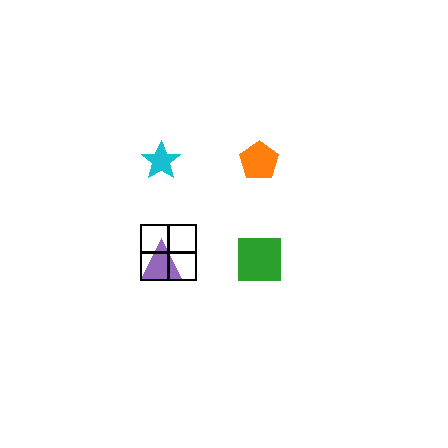

Decoder layers: 28 Image tokens: 256


In [ ]:
if 'model' in globals():
    s=bx_scene(4,98,'diverse',BX_SEED); im=bx_render(s)
    inp=bx_inputs(im,bx_prompt(s)); layout=bx_layout(inp,s)
    overlay=im.copy(); d=ImageDraw.Draw(overlay)
    step=s['canvas']/layout['gw']
    for idx in layout['roi'][s['target']]:
        r,c=divmod(idx-layout['visual'][0],layout['gw'])
        d.rectangle([c*step,r*step,(c+1)*step,(r+1)*step],outline='black',width=2)
    display(overlay)
    print('Decoder layers:',len(bx_layers()),'Image tokens:',len(layout['visual']))
else:
    print('Model adapter preflight awaits loaded model.')

In [ ]:
def bx_run_d(n_scenes=BX_N_SCENES):
    bx_require(); rows=[]
    for j in range(n_scenes):
        seed=BX_SEED+j
        for n in [4,9,16]:
            for reuse in ['factorial','diverse']:
                for spacing in [70,98]:
                    scene=bx_scene(n,spacing,reuse,seed); target=scene['target']; o=scene['objects'][target]
                    for mode in ['rgb','dog','blur','unsharp']:
                        for isolated in [False,True]:
                            # Isolated controls repeated across conditions intentionally, for exact pairing.
                            im,stats=bx_filter(bx_render(scene,only=target if isolated else None),mode)
                            raw,pred=bx_answer(im,bx_prompt(scene,isolated=isolated))
                            gt=bx_pair(o)
                            row=dict(scene_seed=seed,n=n,reuse=reuse,spacing=spacing,filter=mode,
                                     isolated=isolated,target=target,target_color=gt[0],target_shape=gt[1],
                                     eccentricity=math.hypot(o['cx']-BX_CANVAS/2,o['cy']-BX_CANVAS/2),
                                     raw=raw,pred=pred,correct=int(pred==gt),
                                     color_correct=int(pred is not None and pred[0]==gt[0]),
                                     shape_correct=int(pred is not None and pred[1]==gt[1]),
                                     error=bx_error(pred,scene),**stats)
                            rows.append(row)
                    bx_save('D_factorial',rows)  # checkpoint after each layout
    return bx_save('D_factorial',rows)
if BX_RUN_D:
    print('Generation calls:',BX_N_SCENES*3*2*2*4*2)
    bx_d=bx_run_d()
else: print('D off. Set BX_RUN_D=True and rerun this cell.')

Generation calls: 192


### Paired uncertainty, plots and interpretation
Bootstrap the **scene seed**, not every repeated condition as an independent observation. Pilot intervals with two seeds are uninformative. The primary contrast is DoG minus RGB at fixed count/reuse/spacing; compare its scene benefit against its isolated-target benefit. This difference-in-differences is descriptive evidence, not proof of a binding-only mechanism. Pre-register one primary endpoint and reserve separate scenes for choosing filter strength/layers.

mean  count
n  reuse     spacing filter  isolated             
4  diverse   70      blur    False      0.0      2
                             True       0.5      2
                     dog     False      0.0      2
                             True       0.5      2
                     rgb     False      0.0      2
...                                     ...    ...
16 factorial 98      dog     True       0.5      2
                     rgb     False      0.5      2
                             True       0.5      2
                     unsharp False      0.5      2
                             True       0.5      2

[96 rows x 2 columns]

,n,reuse,spacing,effect,lo,hi,n_seeds
0,4,diverse,70,0.0,0.0,0.0,2
1,4,diverse,98,0.0,0.0,0.0,2
2,4,factorial,70,0.5,0.0,1.0,2
3,4,factorial,98,0.0,0.0,0.0,2
4,9,diverse,70,0.0,0.0,0.0,2
5,9,diverse,98,0.0,0.0,0.0,2
6,9,factorial,70,0.0,0.0,0.0,2
7,9,factorial,98,0.0,0.0,0.0,2
8,16,diverse,70,0.0,0.0,0.0,2
9,16,diverse,98,0.0,0.0,0.0,2


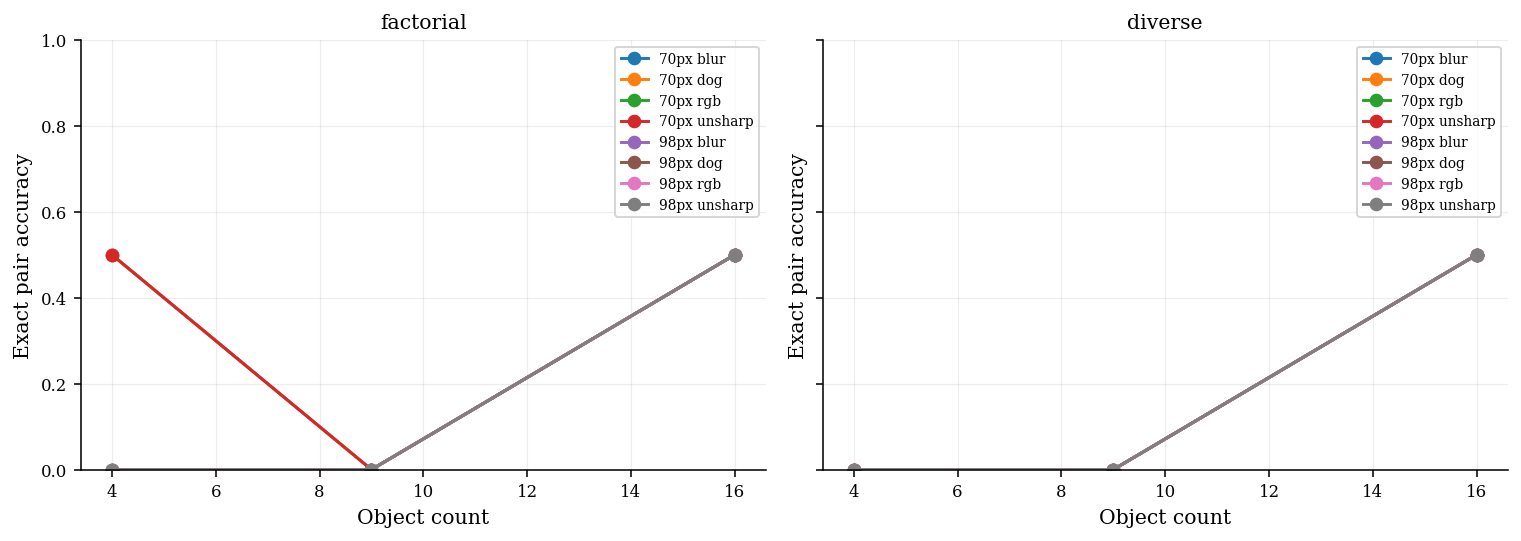

In [ ]:
def bx_boot_mean(values,seed=0,b=2000):
    x=np.asarray(values,dtype=float)
    if len(x)==0: return (float('nan'),)*3
    rng=np.random.default_rng(seed)
    means=x[rng.integers(0,len(x),size=(b,len(x)))].mean(1)
    return float(x.mean()),float(np.quantile(means,.025)),float(np.quantile(means,.975))

def bx_d_contrasts(df):
    idx=['scene_seed','n','reuse','spacing','isolated']
    p=df.pivot(index=idx,columns='filter',values='correct').reset_index()
    p['dog_minus_rgb']=p['dog']-p['rgb']
    q=p.pivot(index=['scene_seed','n','reuse','spacing'],columns='isolated',values='dog_minus_rgb')
    q['scene_minus_isolated']=q[False]-q[True]
    rows=[]
    for key,g in q.reset_index().groupby(['n','reuse','spacing']):
        mean,lo,hi=bx_boot_mean(g['scene_minus_isolated'])
        rows.append(dict(n=key[0],reuse=key[1],spacing=key[2],effect=mean,lo=lo,hi=hi,n_seeds=len(g)))
    return pd.DataFrame(rows)

if 'bx_d' in globals():
    display(bx_d.groupby(['n','reuse','spacing','filter','isolated'])['correct'].agg(['mean','count']))
    display(bx_d_contrasts(bx_d))
    fig,axes=plt.subplots(1,2,figsize=(11,4),sharey=True)
    for ax,reuse in zip(axes,['factorial','diverse']):
        d=bx_d[(bx_d.reuse==reuse)&(~bx_d.isolated)]
        for (spacing,mode),g in d.groupby(['spacing','filter']):
            v=g.groupby('n').correct.mean(); ax.plot(v.index,v.values,marker='o',label=f'{spacing}px {mode}')
        ax.set(title=reuse,xlabel='Object count',ylabel='Exact pair accuracy',ylim=(0,1)); ax.legend(fontsize=7)
    plt.tight_layout(); plt.savefig(BX_OUT/'D_accuracy.png',dpi=160); plt.show()


## E. Revisit panel A: does the grouped key perturbation selectively redirect retrieval?
Estimate a position direction on **calibration scenes only**, with a neutral prompt so the queried shape is not correlated with position. Evaluate on new scenes using a unique-shape cue. Compare no patch, zero-delta sham, position-direction patch, norm-matched random direction, and each single layer. All conditions see exactly the same evaluation scene.

Report both an unconditional destination-color rate and **clean-correct → destination-color** transition rate. Also report full-pair destination switches and invalid outputs. A higher grouped rate alone does not establish synergistic necessity: use leave-one-layer-out effects and unrelated-layer controls before claiming a distributed causal circuit. This cell includes leave-one-out conditions as an option.


In [ ]:
BX_E_N_CALIB=8
BX_E_N_EVAL=8
BX_E_LEAVE_ONE_OUT=False

def bx_key_directions(layers,n=8):
    means={l:[] for l in layers}
    for j in range(n):
        s=bx_scene(4,98,'diverse',BX_SEED+10000+j)
        caps,inp=bx_capture(bx_render(s),'Describe the objects in this image.',[(l,'k') for l in layers])
        layout=bx_layout(inp,s)
        for l in layers:
            k=caps[l,'k']; means[l].append(k[layout['roi'][1]].mean(0)-k[layout['roi'][0]].mean(0))
    return {l:torch.stack(v).mean(0) for l,v in means.items()}

def bx_run_e():
    layers=BX_LAYERS; assert max(layers)<len(bx_layers())
    directions=bx_key_directions(layers,BX_E_N_CALIB)
    gen=torch.Generator().manual_seed(BX_SEED)
    randoms={}
    for l,v in directions.items():
        r=torch.randn(v.shape,generator=gen); randoms[l]=r*v.norm()/r.norm().clamp_min(1e-9)
    rows=[]
    for j in range(BX_E_N_EVAL):
        s=bx_scene(4,98,'diverse',BX_SEED+20000+j); s['target']=0
        im=bx_render(s); prompt=bx_prompt(s,cue='shape'); inp=bx_inputs(im,prompt); layout=bx_layout(inp,s)
        a,b=bx_pair(s['objects'][0]),bx_pair(s['objects'][1])
        conditions=[('clean',[],0),('sham',layers,0),('group',layers,1),('random',layers,1)]
        conditions += [(f'single_{l}',[l],1) for l in layers]
        if BX_E_LEAVE_ONE_OUT: conditions += [(f'without_{l}',[x for x in layers if x!=l],1) for l in layers]
        clean=None
        for name,ls,alpha in conditions:
            specs=[]
            for l in ls:
                v=(randoms if name=='random' else directions)[l]*alpha
                for obj,sign in [(0,1),(1,-1)]:
                    pos=layout['roi'][obj]
                    specs.append(dict(layer=l,kind='k',positions=pos,value=sign*v.expand(len(pos),-1),op='add',heads=BX_KV_HEADS))
            raw,pred=bx_answer(im,prompt,specs)
            if name=='clean': clean=pred
            rows.append(dict(scene_seed=s['seed'],condition=name,raw=raw,pred=pred,
                clean_correct=int(clean==a),correct=int(pred==a),valid=int(pred is not None),
                destination_color=int(pred is not None and pred[0]==b[0]),destination_pair=int(pred==b),
                target_pair=a,destination=b))
        bx_save('E_key_controls',rows)
    return bx_save('E_key_controls',rows)
if BX_RUN_E:
    print("Running E")
    bx_e=bx_run_e()
    display(bx_e.groupby('condition')[['correct','destination_color','destination_pair','valid']].mean())
    eligible=bx_e[bx_e.clean_correct==1]
    display(eligible.groupby('condition').destination_color.agg(['mean','count']))


,correct,destination_color,destination_pair,valid
condition,,,,
clean,0.500,0.00,0.000,0.625
group,0.125,0.25,0.125,0.750
random,0.500,0.00,0.000,0.625
sham,0.500,0.00,0.000,0.625
single_21,0.375,0.00,0.000,0.625
single_22,0.500,0.00,0.000,0.625
single_23,0.500,0.00,0.000,0.625
single_24,0.500,0.00,0.000,0.625
single_25,0.375,0.00,0.000,0.625


,mean,count
condition,,
clean,0.0,4
group,0.0,4
random,0.0,4
sham,0.0,4
single_21,0.0,4
single_22,0.0,4
single_23,0.0,4
single_24,0.0,4
single_25,0.0,4


## F. Revisit panel B: separate address transfer from donor-feature transfer
Use two objects at equal height. Recipient query asks for left or right (counterbalanced across scenes). Donor query asks for the same or opposite side. **Independently**, donor attributes are unchanged or replaced by disjoint colors/shapes. This yields a 2×2 address × content design.

- **Q patch:** copy donor last-prompt Q into recipient last-prompt Q. Predicted address-transfer signature: recipient object's attributes at the donor-selected side, including when donor attributes are disjoint.
- **V patch:** copy donor V at recipient-target ROI positions. Predicted feature-transfer signature: donor attributes at that fixed side.
- **Q+V:** tests combined effects, not necessarily an additive mechanism.
- Self-donor sham and random deltas control general disruption. Test single layers as well as the candidate band on an independent localization split.

Q and V are **routing/content intervention proxies**, not pure where/what representations. Q can carry content; V can carry position. Only selective cross-content generalization supports the intended interpretation. Patching different prompts can transfer instruction semantics too. A positive effect still needs a position-ID-specific subspace intervention for a strong symbolic-address claim.


In [ ]:
def bx_two_scene(seed=0, donor=False):
    rng=random.Random(seed)
    colors=rng.sample(list(BX_COLORS),4); shapes=rng.sample(BX_SHAPES,4)
    offset=2 if donor else 0
    objs=[]
    for i,cx in enumerate([140,308]):
        objs.append(dict(color=colors[offset+i],shape=shapes[offset+i],cx=cx,cy=224,
                         bbox=[cx-21,203,cx+21,245],row=1,col=i+1))
    return dict(objects=objs,target=0,n=2,spacing=168,reuse='disjoint',seed=seed,canvas=448)

def bx_side_prompt(side):
    return f"What color and shape is the {'leftmost' if side==0 else 'rightmost'} object? Reply with exactly two words: color shape."

def bx_run_f(n=8):
    layers=BX_LAYERS; requests=[(l,k) for l in layers for k in ['q','v']]; rows=[]
    for j in range(n):
        seed=BX_SEED+30000+j; rec=bx_two_scene(seed); target=j%2; rec['target']=target
        im=bx_render(rec); prompt=bx_side_prompt(target)
        rcaps,rinp=bx_capture(im,prompt,requests); rl=bx_layout(rinp,rec)
        raw,clean=bx_answer(im,prompt)
        rows.append(dict(scene_seed=seed,condition='clean',address_flip=False,content_change=False,
                         raw=raw,pred=clean,clean_correct=int(clean==bx_pair(rec['objects'][target])),
                         recipient_target=int(clean==bx_pair(rec['objects'][target]))))
        for flip in [False,True]:
            side=1-target if flip else target
            for changed in [False,True]:
                donor=bx_two_scene(seed,donor=changed); donor['target']=side
                dcaps,dinp=bx_capture(bx_render(donor),bx_side_prompt(side),requests)
                dl=bx_layout(dinp,donor)
                for mode in ['q','v','qv','random_qv']:
                    specs=[]
                    for l in layers:
                        for kind in (['q','v'] if mode in ['qv','random_qv'] else [mode]):
                            dst=[rinp['input_ids'].shape[1]-1] if kind=='q' else rl['roi'][target]
                            src=[dinp['input_ids'].shape[1]-1] if kind=='q' else dl['roi'][target]
                            value=dcaps[l,kind][src].clone(); assert len(src)==len(dst)
                            if mode=='random_qv':
                                orig=rcaps[l,kind][dst]; delta=value-orig
                                gen=torch.Generator().manual_seed(seed+l+(0 if kind=='q' else 100))
                                noise=torch.randn(delta.shape,generator=gen)
                                value=orig+noise*delta.norm()/noise.norm().clamp_min(1e-9)
                            specs.append(dict(layer=l,kind=kind,positions=dst,value=value,
                                              heads=BX_QUERY_HEADS if kind=='q' else BX_KV_HEADS))
                    raw,pred=bx_answer(im,prompt,specs)
                    rows.append(dict(scene_seed=seed,condition=mode,address_flip=flip,content_change=changed,
                        raw=raw,pred=pred,valid=int(pred is not None),
                        clean_correct=int(clean==bx_pair(rec['objects'][target])),
                        recipient_target=int(pred==bx_pair(rec['objects'][target])),
                        recipient_at_donor_address=int(pred==bx_pair(rec['objects'][side])),
                        donor_at_target=int(pred==bx_pair(donor['objects'][target])),
                        donor_at_donor_address=int(pred==bx_pair(donor['objects'][side]))))
        bx_save('F_address_content',rows)
    return bx_save('F_address_content',rows)
if BX_RUN_F:
    bx_f=bx_run_f()
    # # The disjoint-content, flipped-address subset discriminates address from answer copying.
    # display(bx_f[(bx_f.content_change==True)&(bx_f.address_flip==True)&(bx_f.clean_correct==1)]
    #         .groupby('condition')[['recipient_at_donor_address','donor_at_target','donor_at_donor_address','valid']].agg(['mean','count']))


    # Expanded F experiment: 1000 NEW scenes.
    # Runs directly when this cell executes; no BX_RUN_F flag needed.
    # Uses the existing bx_run_f(n=...) function defined above.

    BX_F_N_TRIALS = 1000

    # Preserve the pilot outputs and use a fresh scene seed range.
    _previous_seed = BX_SEED
    _previous_out = BX_OUT
    f_output = (
        Path("binding_runs")
        / ("F_expanded_" + datetime.datetime.now().strftime("%Y%m%d_%H%M%S"))
    )
    f_output.mkdir(parents=True, exist_ok=False)

    print(f"Running {BX_F_N_TRIALS} scenes.")
    print(f"Approximately {17 * BX_F_N_TRIALS:,} generated responses,")
    print("plus activation-capture passes. This may take a while.")
    print("Results:", f_output)

    try:
        BX_SEED = _previous_seed + 500_000
        BX_OUT = f_output
        bx_f = bx_run_f(n=BX_F_N_TRIALS)
    finally:
        BX_SEED = _previous_seed
        BX_OUT = _previous_out

    # How many scenes were answered correctly BEFORE intervention?
    clean = bx_f[bx_f["condition"] == "clean"]
    n_correct = int(clean["clean_correct"].sum())

    print(
        f"\nInitially correct: {n_correct}/{len(clean)} "
        f"({n_correct / len(clean):.1%})"
    )

    # Main diagnostic condition:
    # donor selects opposite position AND has different attributes.
    diagnostic = bx_f[
        (bx_f["address_flip"] == True)
        & (bx_f["content_change"] == True)
    ].copy()


    def wilson_interval(k, n):
        """95% interval for a binomial proportion."""
        if n == 0:
            return np.nan, np.nan
        z = 1.959963984540054
        p = k / n
        denominator = 1 + z**2 / n
        center = (p + z**2 / (2 * n)) / denominator
        half = (
            z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
            / denominator
        )
        return max(0, center - half), min(1, center + half)


    rates = []
    comparisons = []

    for subset_name, subset in [
        ("all_scenes", diagnostic),
        ("initially_correct", diagnostic[diagnostic["clean_correct"] == 1]),
    ]:
        if subset.empty:
            print(f"No eligible scenes for: {subset_name}")
            continue

        for condition, group in subset.groupby("condition"):
            k = int(group["recipient_at_donor_address"].sum())
            n = len(group)
            lo, hi = wilson_interval(k, n)

            rates.append({
                "subset": subset_name,
                "condition": condition,
                "switches": k,
                "trials": n,
                "switch_rate": k / n,
                "95%_lower": lo,
                "95%_upper": hi,
                "valid_response_rate": group["valid"].mean(),
            })

        # Paired comparison: each condition uses the SAME scenes.
        paired = subset.pivot(
            index="scene_seed",
            columns="condition",
            values="recipient_at_donor_address",
        )
        assert not paired.isna().any().any(), "Missing paired conditions."

        for control in ["random_qv", "v", "qv"]:
            differences = (paired["q"] - paired[control]).to_numpy(float)
            rng = np.random.default_rng(731)
            boot = np.array([
                rng.choice(
                    differences, size=len(differences), replace=True
                ).mean()
                for _ in range(5000)
            ])

            comparisons.append({
                "subset": subset_name,
                "comparison": f"q minus {control}",
                "paired_trials": len(differences),
                "rate_difference": differences.mean(),
                "95%_lower": np.quantile(boot, 0.025),
                "95%_upper": np.quantile(boot, 0.975),
            })

    rate_table = pd.DataFrame(rates)
    comparison_table = pd.DataFrame(comparisons)

    rate_table.to_csv(f_output / "F_switch_rates.csv", index=False)
    comparison_table.to_csv(f_output / "F_paired_comparisons.csv", index=False)

    print("\nSwitch rates and 95% intervals:")
    display(rate_table)

    print("\nPaired differences between interventions:")
    display(comparison_table)

    print("\nInspect these formatting failures before interpreting low accuracy:")
    display(
        diagnostic[diagnostic["valid"] == 0][
            ["scene_seed", "condition", "raw"]
        ].head(20)
    )


Running 1000 scenes.
Approximately 17,000 generated responses,
plus activation-capture passes. This may take a while.
Results: binding_runs/F_expanded_20260925_163327


## G. Token-location tracing and optional Sixuan head validation
Hold the prompt and all geometry fixed; change only the target's color in the donor image. Replace selected K/V rows at one layer: target ROI, other-object ROIs, background, or text tokens. Compare donor replacement to self replacement for each group. Different group sizes mean these are total interventions, **not normalized measures of per-token importance**.

A text-token effect means visual information was carried by text-token activations at that layer, not that the information originated in language. Background effects likewise concern contextualized token locations. This distinction is motivated by Cui et al.'s dual-mechanism results.

If Sixuan supplies actual `(layer, query_head)` indices for this exact checkpoint, the optional o_proj-input patch validates those heads without conflating GQA KV heads. Add matched unrelated heads to the list and mark them as controls in analysis. Do not transfer head indices from Qwen2.5 to Qwen2 without relocalization.


In [ ]:
BX_G_LAYER=24

def bx_run_g(n=8):
    rows=[]; l=BX_G_LAYER
    for j in range(n):
        s=bx_scene(4,98,'diverse',BX_SEED+40000+j); im=bx_render(s); prompt=bx_prompt(s)
        donor=json.loads(json.dumps(s)); t=s['target']; orig=bx_pair(s['objects'][t])
        used={o['color'] for o in s['objects']}
        donor['objects'][t]['color']=next(c for c in BX_COLORS if c not in used)
        dest=bx_pair(donor['objects'][t])
        req=sorted(set([(l,'k'),(l,'v')]+[(a,'o') for a,h in BX_SIXUAN_HEADS]))
        rc,ri=bx_capture(im,prompt,req); dc,di=bx_capture(bx_render(donor),prompt,req)
        assert torch.equal(ri['input_ids'],di['input_ids'])
        masks=bx_layout(ri,s); groups={'target':masks['roi'][t],
            'other_objects':sorted(set(masks['foreground'])-set(masks['roi'][t])),
            'background':masks['background'],'text':masks['text']}
        raw,clean=bx_answer(im,prompt)
        for group,pos in groups.items():
            for source,caps in [('self',rc),('donor',dc)]:
                specs=[dict(layer=l,kind=k,positions=pos,value=caps[l,k][pos],heads=BX_KV_HEADS) for k in ['k','v']]
                raw,pred=bx_answer(im,prompt,specs)
                rows.append(dict(scene_seed=s['seed'],group=group,source=source,n_tokens=len(pos),raw=raw,pred=pred,
                                 clean_correct=int(clean==orig),correct=int(pred==orig),donor_pair=int(pred==dest)))
        for layer,head in BX_SIXUAN_HEADS:
            pos=[ri['input_ids'].shape[1]-1]
            for source,caps in [('self',rc),('donor',dc)]:
                specs=[dict(layer=layer,kind='o',positions=pos,value=caps[layer,'o'][pos],heads=[head])]
                raw,pred=bx_answer(im,prompt,specs)
                rows.append(dict(scene_seed=s['seed'],group=f'L{layer}H{head}_output',source=source,n_tokens=1,
                    raw=raw,pred=pred,clean_correct=int(clean==orig),correct=int(pred==orig),donor_pair=int(pred==dest)))
        bx_save('G_token_locations',rows)
    return bx_save('G_token_locations',rows)
if BX_RUN_G:
    bx_g=bx_run_g()
    display(bx_g.groupby(['group','source'])[['correct','donor_pair']].agg(['mean','count']))

correct       donor_pair      
                        mean count       mean count
group         source                               
background    donor    0.375     8        0.0     8
              self     0.375     8        0.0     8
other_objects donor    0.375     8        0.0     8
              self     0.375     8        0.0     8
target        donor    0.125     8        0.0     8
              self     0.375     8        0.0     8
text          donor    0.375     8        0.0     8
              self     0.375     8        0.0     8

## H. Optional trainable attention + phase comparator
This is a **small original comparator**, not an implementation of the published KoPE architecture. It takes image patches and a target coordinate, predicts the target color/shape, and adds a phase-similarity bias to self-attention. Phases evolve by a differentiable Kuramoto-like update whose affinities come from model features, never ground-truth object masks.

Train three variants with identical parameter counts, minibatch order, optimizer and update budget: ordinary attention (phase branch disconnected), static phase bias, and evolving phase bias. Static bias controls for phase features without synchronization dynamics. The unused phase parameters in the ordinary baseline make counts equal but not active computational capacity; report runtime too.

For the evolving model evaluate normal phases, coupling disabled, and shuffled phases. Generalization tests: higher object count, tighter spacing, and held-out color–shape conjunctions. A selective phase-disruption effect supports dependence on the added mechanism; it does not establish biological synchrony or explain Qwen's mechanism. Layer depth here is computational iteration, not measured neuronal time. Loss combines color and shape supervision; exact-pair accuracy is the binding outcome.

This experiment starts from scratch on 56×56 rendered scenes and must be reported separately from Qwen. A 2-step smoke run tests plumbing only; use learning curves, >=3 seeds, converged baselines, tuning on a separate validation split, and matched compute before scientific claims.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import time

class BXPhaseNet(nn.Module):
    def __init__(self,mode='attention',dim=48,heads=4,depth=2):
        super().__init__(); assert mode in ['attention','static','phase']
        self.mode=mode; self.heads=heads; self.dim=dim; self.depth=depth
        self.patch=nn.Conv2d(3,dim,7,7)  # 56px -> 8x8 tokens
        self.pos=nn.Parameter(torch.randn(1,64,dim)*.02)
        self.phase_init=nn.Linear(dim,1)
        self.qkv=nn.ModuleList([nn.Linear(dim,3*dim) for _ in range(depth)])
        self.proj=nn.ModuleList([nn.Linear(dim,dim) for _ in range(depth)])
        self.norm=nn.ModuleList([nn.LayerNorm(dim) for _ in range(depth)])
        self.ff=nn.ModuleList([nn.Sequential(nn.Linear(dim,2*dim),nn.GELU(),nn.Linear(2*dim,dim)) for _ in range(depth)])
        self.read_q=nn.Linear(2,dim); self.out=nn.Linear(dim,18)
    def forward(self,images,coords,phase_control='normal'):
        x=self.patch(images).flatten(2).transpose(1,2)+self.pos
        theta=math.pi*torch.tanh(self.phase_init(x).squeeze(-1))
        b,n,d=x.shape
        for layer in range(self.depth):
            z=self.norm[layer](x)
            q,k,v=self.qkv[layer](z).reshape(b,n,3,self.heads,d//self.heads).permute(2,0,3,1,4)
            logits=q@k.transpose(-1,-2)/math.sqrt(d//self.heads)
            if self.mode!='attention':
                if self.mode=='phase' and phase_control!='no_coupling':
                    aff=(F.normalize(z,dim=-1)@F.normalize(z,dim=-1).transpose(-1,-2)).softmax(-1)
                    for _ in range(3):
                        theta=theta+.3*(aff*torch.sin(theta[:,None,:]-theta[:,:,None])).sum(-1)
                current=theta
                if phase_control=='shuffle':
                    # Per-example random token permutation: destroys feature-phase association.
                    order=torch.rand(b,n,device=x.device).argsort(-1)
                    current=current.gather(1,order)
                logits=logits+torch.cos(current[:,:,None]-current[:,None,:])[:,None]
            y=(logits.softmax(-1)@v).transpose(1,2).reshape(b,n,d)
            x=x+self.proj[layer](y); x=x+self.ff[layer](self.norm[layer](x))
        query=self.read_q(coords)
        weights=(x*query[:,None]).sum(-1).div(math.sqrt(d)).softmax(-1)
        return self.out((x*weights[:,:,None]).sum(1))

def bx_toy_batch(seed,batch=16,n=4,spacing=98,split='train'):
    rng=random.Random(seed); images=[]; coords=[]; labels=[]
    color_names=list(BX_COLORS)
    # Balanced held-out pairs; every feature occurs in training and test.
    pool=[(c,s) for ci,c in enumerate(color_names) for si,s in enumerate(BX_SHAPES)
          if ((ci+si)%4==0)==(split=='heldout')]
    for j in range(batch):
        scene=bx_scene(n,spacing,'diverse',rng.randrange(10**9))
        pairs=rng.sample(pool,n)
        for o,(c,s) in zip(scene['objects'],pairs): o.update(color=c,shape=s)
        t=scene['objects'][scene['target']]
        images.append(np.asarray(bx_render(scene).resize((56,56),Image.Resampling.LANCZOS),dtype=np.float32).transpose(2,0,1)/255)
        coords.append([t['cx']/448*2-1,t['cy']/448*2-1])
        labels.append([color_names.index(t['color']),BX_SHAPES.index(t['shape'])])
    return torch.tensor(np.stack(images)),torch.tensor(coords),torch.tensor(labels)

def bx_train_toy(seed,mode,steps=200,batch=16,device='cpu'):
    torch.manual_seed(seed); net=BXPhaseNet(mode).to(device)
    opt=torch.optim.AdamW(net.parameters(),lr=3e-4); history=[]; start=time.perf_counter()
    for step in range(steps):
        im,coord,y=[v.to(device) for v in bx_toy_batch(seed*100000+step,batch)]
        net.train(); opt.zero_grad(set_to_none=True); out=net(im,coord)
        loss=F.cross_entropy(out[:,:9],y[:,0])+F.cross_entropy(out[:,9:],y[:,1])
        loss.backward(); opt.step()
        history.append(dict(seed=seed,mode=mode,step=step,loss=float(loss.detach())))
    return net,history,time.perf_counter()-start

@torch.inference_mode()
def bx_eval_toy(net,seed,n=4,spacing=98,split='test',control='normal',batches=8,batch=16):
    net.eval(); rows=[]; device=next(net.parameters()).device
    torch.manual_seed(seed)  # repeatable shuffle-control noise
    for j in range(batches):
        im,coord,y=[v.to(device) for v in bx_toy_batch(seed+j,batch,n,spacing,split)]
        out=net(im,coord,control)
        pred=torch.stack([out[:,:9].argmax(-1),out[:,9:].argmax(-1)],-1)
        for ok in (pred==y).all(-1).cpu().tolist(): rows.append(int(ok))
    return float(np.mean(rows)),len(rows)

BX_H_STEPS=200  # demonstration budget, NOT a convergence claim
BX_H_SEEDS=[0,1,2]
if BX_RUN_H:
    device='cuda' if torch.cuda.is_available() else 'cpu'
    results=[]; curves=[]
    for seed in BX_H_SEEDS:
        for mode in ['attention','static','phase']:
            net,hist,seconds=bx_train_toy(seed,mode,BX_H_STEPS,device=device); curves+=hist
            torch.save(net.state_dict(),BX_OUT/f'H_{mode}_seed{seed}.pt')
            for n,spacing,split in [(4,98,'test'),(9,98,'test'),(4,70,'test'),(4,98,'heldout')]:
                for control in (['normal','no_coupling','shuffle'] if mode=='phase' else ['normal']):
                    acc,total=bx_eval_toy(net,900000+seed*1000,n,spacing,split,control)
                    results.append(dict(seed=seed,mode=mode,n=n,spacing=spacing,split=split,control=control,
                                        accuracy=acc,n_eval=total,train_seconds=seconds,
                                        parameter_count=sum(p.numel() for p in net.parameters())))
            bx_save('H_evaluation',results); bx_save('H_training',curves)
            del net
            if torch.cuda.is_available(): torch.cuda.empty_cache()
    bx_h=bx_save('H_evaluation',results); display(bx_h)
else: print('H off: standalone trainable comparator, no modification to Qwen.')

,seed,mode,n,spacing,split,control,accuracy,n_eval,train_seconds,parameter_count
0,0,attention,4,98,test,normal,0.000000,128,11.997114,48979
1,0,attention,9,98,test,normal,0.000000,128,11.997114,48979
2,0,attention,4,70,test,normal,0.000000,128,11.997114,48979
3,0,attention,4,98,heldout,normal,0.046875,128,11.997114,48979
4,0,static,4,98,test,normal,0.000000,128,12.200890,48979
5,0,static,9,98,test,normal,0.000000,128,12.200890,48979
6,0,static,4,70,test,normal,0.000000,128,12.200890,48979
7,0,static,4,98,heldout,normal,0.046875,128,12.200890,48979
8,0,phase,4,98,test,normal,0.000000,128,13.148050,48979
9,0,phase,4,98,test,no_coupling,0.000000,128,13.148050,48979


## Checks to run before scaling
These check hooks (including exception cleanup and query-head channel isolation), parsing and basic model forward/backward behavior. They are not a substitute for a Qwen GPU smoke run. Use `BX_CHECK_TOY=True` to run the tiny toy gradient check. Self-patch equality in the real checkpoint is required before interpreting donor patches; if generation changes under exact self replacement, stop and inspect numerical/hook behavior.

**Preparation-time validation:** all code cells compiled; CPU stimulus generation, strict response parser, and statistics executed; hook channel isolation, one-shot behavior and exception cleanup passed with a NumPy tensor test double. PyTorch and Qwen execution were unavailable here. Run the supplied real-model self-patch checks and optional toy gradient check in your GPU runtime.


In [ ]:
BX_CHECK_TOY=True
if BX_CHECK_TOY:
    torch.manual_seed(0)
    x,c,y=bx_toy_batch(1,batch=2)
    counts=[]
    for mode in ['attention','static','phase']:
        net=BXPhaseNet(mode); out=net(x,c)
        assert out.shape==(2,18) and torch.isfinite(out).all()
        loss=F.cross_entropy(out[:,:9],y[:,0])+F.cross_entropy(out[:,9:],y[:,1]); loss.backward()
        assert net.patch.weight.grad is not None and torch.isfinite(net.patch.weight.grad).all()
        counts.append(sum(p.numel() for p in net.parameters()))
    assert len(set(counts))==1
    print('Toy forward/backward and parameter-count checks passed.')

if 'bx_e' in globals():
    p=bx_e.pivot(index='scene_seed',columns='condition',values='raw')
    assert (p['clean']==p['sham']).all(), 'Sham changed a generated answer. Investigate before interpretation.'
if 'bx_f' in globals():
    clean=bx_f[bx_f.condition=='clean'].set_index('scene_seed').raw
    sham=bx_f[(bx_f.condition=='qv')&(~bx_f.address_flip)&(~bx_f.content_change)].set_index('scene_seed').raw
    assert (clean==sham).all(), 'Self-donor Q/V changed output.'
if 'bx_g' in globals():
    print('Check donor versus self effects by token group; use matched unrelated heads as controls.')

Toy forward/backward and parameter-count checks passed.
Check donor versus self effects by token group; use matched unrelated heads as controls.


In [ ]:
import time
time.sleep(30)